# Avance 4. Modelos alternativos

El objetivo de este notebook es construir múltiples modelos (individuales, no ensambles) relevantes para realizar el pronóstico y evaluar su desempeño. Diferentes algoritmos pueden comportarse de manera óptima en diferentes tipos de datos o tareas. La construcción de modelos alternativos permite explorar y evaluar cuál de ellos proporciona el mejor rendimiento para un problema particular. Para esto será necesario:

* Explorar una gama diversa de técnicas y enfoques con el fin de identificar el de mejor desempeño en el conjunto de datos en cuestión.

* Encontrar la configuración óptima que maximiza el rendimiento del modelo en una tarea específica.

## 1. Librerías y Carga de Datos.

* Se define si se utilizará Plotly para las gráficas y se importan las librerías necesarias para análisis de datos, visualización y modelado de series temporales.

Recomendaciones:  Para un mejor entendimiento de las gráficas o su uso local cambiar el valor de `USE_PLOTRLY` a `True`

In [101]:
# Control de visualización: desactivar Plotly para generar gráficas con Matplotlib/Seaborn en este notebook.
USE_PLOTLY = False
# Nota: Plotly puede habilitarse para uso local cambiando a True si se desea interactividad.

### 1.1. Librerías

* Sistema

In [102]:
import sys
sys.path.append('../../')

* Fucniones personalizadas

In [103]:
import src.utils.helpers as func
from src.utils.helpers import setup_logging
import src.evaluation.metrics as meval
from src.features.build_features import prepare_data
from src.utils.ts_diagnostics import StationarityAnalyzer, analyze_decomposition
from src.visualization import tsa_plots as tsp
from src.evaluation.plots import plot_residuals_distribution, plot_forecast, plot_prophet_forecast, plot_predictions
from src.features.build_features import prepare_data, add_lags
from src.features.prophet_preprocessing import prophet_df, get_weekly_holidays_df, prepare_custom_holidays
from src.evaluation.validation import cross_validation_prophet
setup_logging(root_level="WARNING", prophet_level="WARNING", cmdstanpy_level="WARNING", silence_cmdstanpy=True)

* Statsmodels

In [104]:
from statsmodels.tsa.api import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

* Sklearn

In [105]:
from sklearn.metrics import mean_squared_error, make_scorer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler

* Otros

In [203]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from xgboost import XGBRegressor
from prophet import Prophet
# import warnings
import plotly.offline as py
py.init_notebook_mode()
# warnings.filterwarnings("ignore")
from tqdm.notebook import tqdm

### 1.2. Carga de Datos

In [107]:
# Usar df_log como dataset base para estos modelos
# path = r'C:\Users\naomi\proyecto_depresion\proyecto-integrador-mna\data\processed\df_log.parquet'
path = '../../data/processed/df_log.parquet'

# Cargar datos (sin mostrar información para reducir salida de notebook)
df_log = func.load_data(path, show_info=False)

Cargando datos desde: ../../data/processed/df_log.parquet
Datos cargados exitosamente.


### 1.3 Argumentos Comunes para Graficar

In [108]:
# Los parámetros comunes del gráfico
common_plot_args = {
    'plotly_engine': USE_PLOTLY,
    'hover_mode': 'x unified',
}

## 2. Modelos clásicos

### 2.1. Baseline: Holt-Winters
* Se ordena el DataFrame por fecha, se establece el índice temporal y se divide el conjunto de datos en entrenamiento (80%) y prueba (20%) para validar el modelo.

In [109]:
# índice temporal
data = df_log.copy().sort_values('fecha')
data = data.set_index('fecha').asfreq('W-MON')

scaled_method = 'log'
train, test = func.split_series(data, train_size=0.8)

Total de datos: 573
Tamaño del conjunto de entrenamiento: 458
Tamaño del conjunto de prueba: 115


* Se ajusta el modelo de suavizamiento exponencial doble utilizando únicamente el conjunto de entrenamiento.

In [110]:
model_triple = ExponentialSmoothing(
    train, 
    seasonal_periods=52, 
    trend='mul', 
    seasonal='add')

model_triple_fit = model_triple.fit()

* Se realiza el pronóstico para el periodo de prueba utilizando el modelo ajustado.

In [111]:
forecast_triple = model_triple_fit.forecast(115)

* Se transforman los valores ajustados y pronosticados de la escala logarítmica a la escala original para facilitar la interpretación

In [112]:
method = 'log'
train_org = func.get_original_scale_dataframe(train, method=scaled_method)
test_org = func.get_original_scale_dataframe(test, method=scaled_method)
df_original = func.get_original_scale_dataframe(data, method=method)
df_ajustado = func.get_original_scale_dataframe(model_triple_fit.fittedvalues, method=method)
df_pronostico = func.get_original_scale_dataframe(forecast_triple, method=method)

#### 2.1.1. Evaluación del modelo

##### 2.1.1.1. MAE, RMSE y MAPE
* Se calculan las métricas de error tanto en el conjunto de entrenamiento como en el de prueba para cuantificar la precisión del modelo.

In [113]:
model_metrics = meval.evaluate_model_performance(train_org,test_org,df_ajustado,df_pronostico, label= 'valor_original')

Evaluating model performance...

Evaluación del modelo en el conjunto Train:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 178.691    │
├───────────┼────────────┤
│ RMSE      │ 254.155    │
├───────────┼────────────┤
│ MAPE      │   0.165696 │
╘═══════════╧════════════╛

Evaluación del modelo en el conjunto Test:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 364.08     │
├───────────┼────────────┤
│ RMSE      │ 502.859    │
├───────────┼────────────┤
│ MAPE      │   0.147398 │
╘═══════════╧════════════╛


El análisis del modelo de Holt-Winters revela un comportamiento que sugiere una pérdida de precisión en el error absoluto al evaluar la capacidad de generalización. En el conjunto de entrenamiento, el modelo ajusta la serie con un Error Absoluto Medio (MAE) de $178.69$ y una Raíz del Error Cuadrático Medio (RMSE) de $254.16$. No obstante, al pronosticar sobre el conjunto de prueba, los errores absolutos se incrementan notablemente a MAE de $364.08$ y RMSE de $502.86$, lo que indica que el modelo no extrapola con precisión los valores exactos en unidades de casos no vistos. Pese a este deterioro en el error absoluto, el Error Porcentual Absoluto Medio (MAPE) en la prueba es inferior ($14.74\%$) al de entrenamiento ($16.57\%$). Este patrón sugiere que, aunque el error de pronóstico es mayor en magnitud, es proporcionalmente menor respecto a los valores reales de la serie en el periodo de prueba, demostrando una estabilidad porcentual aceptable y una capacidad robusta para capturar la tendencia subyacente y la estacionalidad del fenómeno.

##### 2.1.1.2. Análisis de errores
* Se realiza una visualización para análisis de errores (residuos)

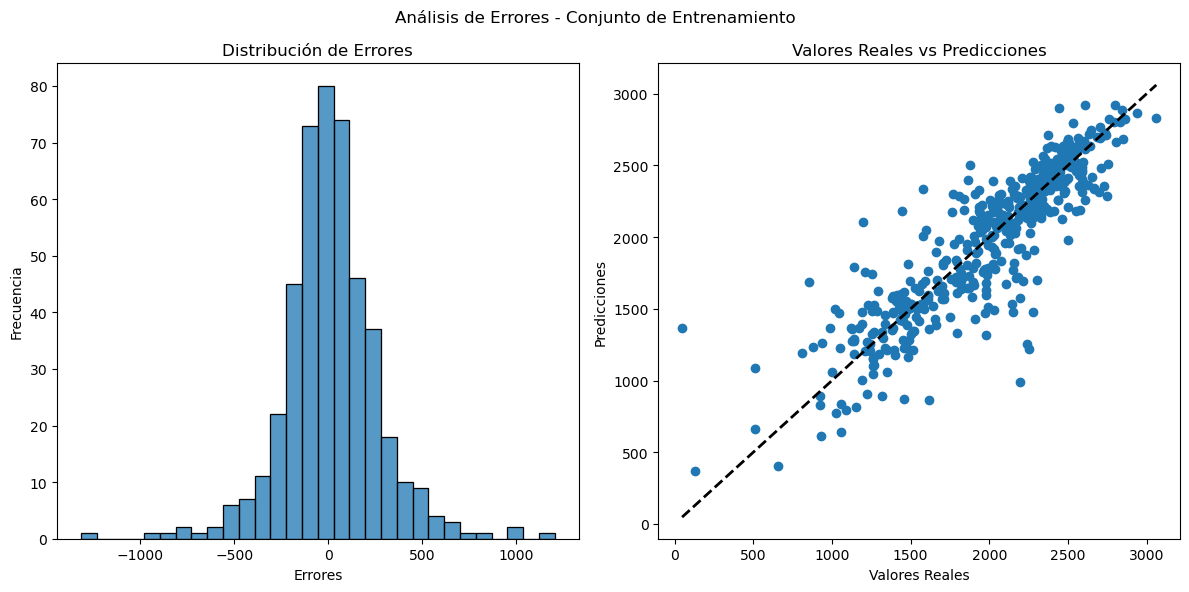

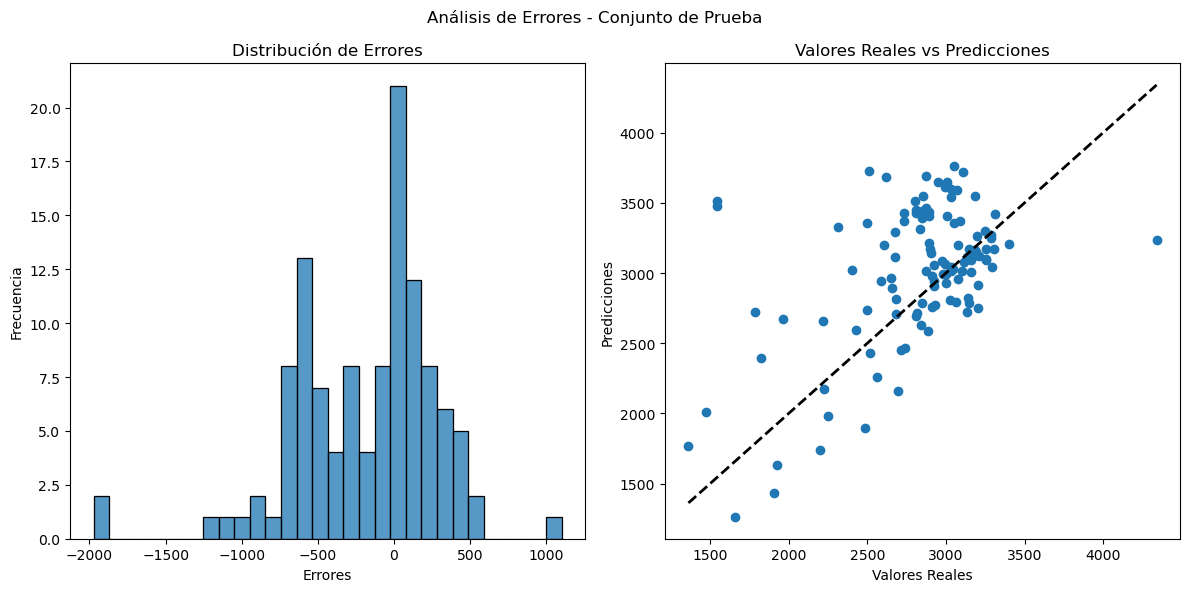

In [114]:
plot_residuals_distribution(train_org,df_ajustado, plotly_engine = USE_PLOTLY, title = 'Análisis de Errores - Conjunto de Entrenamiento')
plot_residuals_distribution(test_org, df_pronostico, plotly_engine = USE_PLOTLY, title = 'Análisis de Errores - Conjunto de Prueba')

En el **conjunto de Entrenamiento**, el histograma de errores se concentra fuertemente en torno a cero, y el gráfico de **Valores Reales vs Predicciones** muestra que los puntos de predicción (naranja) se alinean estrechamente con la **recta de $45^{\circ}$** (línea discontinua), indicando que el modelo replica con alta precisión los datos históricos. En el **conjunto de Prueba**, el histograma de errores sigue manteniendo su centro alrededor de cero, y aunque los puntos en el gráfico de **Valores Reales vs Predicciones** presentan una **mayor dispersión** alrededor de la línea de $45^{\circ}$ en comparación con el entrenamiento, esta **variabilidad es esperable** en datos fuera de muestra y confirma que el modelo no presenta un sesgo sistemático (los errores son aproximadamente simétricos a cero), lo que valida su **capacidad para generar pronósticos imparciales** de los casos semanales de depresión.

#### 2.1.2. Visualización de resultados

##### 2.1.2.1. Entrenamiento y prueba
* Se grafican los datos originales, los valores ajustados y el pronóstico para comparar el desempeño del modelo.

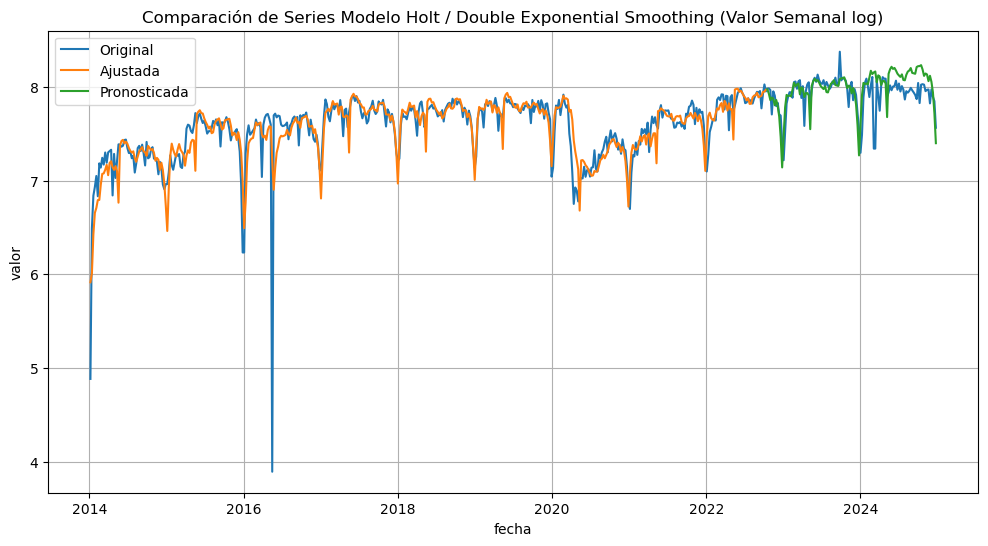

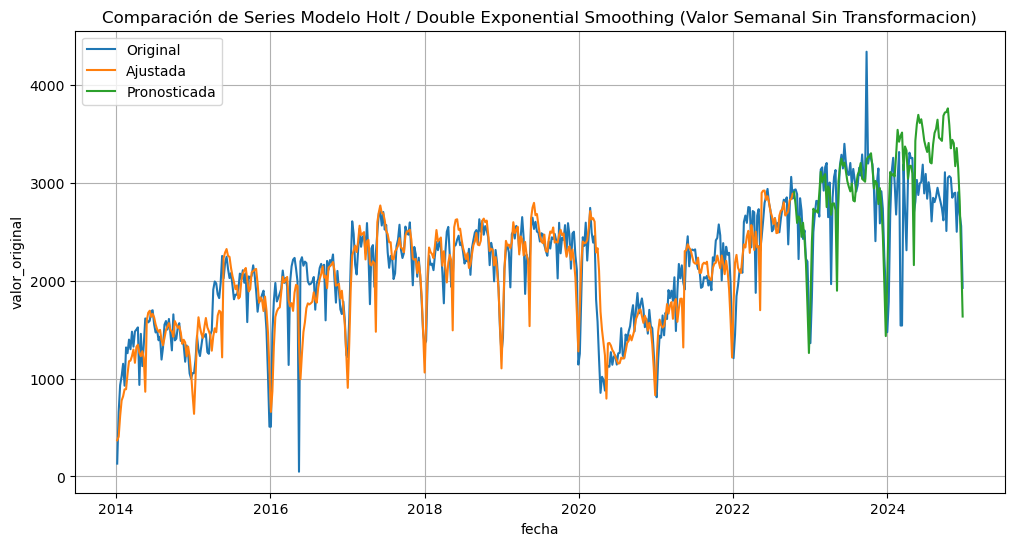

In [115]:

# Los datos a graficar
model_name = 'Modelo Holt / Double Exponential Smoothing'
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'),
)

# El gráfico base que siempre se muestra
plot_configs = [
    ('valor', 'Valor Semanal log')
]

# El gráfico condicional
if 'valor_original' in df_original.columns:
    plot_configs.append(('valor_original', 'Valor Semanal Sin Transformacion'))


# --- 3. Itera y llama a la función UNA SOLA VEZ dentro del bucle ---
for y_col, title_suffix in plot_configs:
    plot_forecast(
        *data_tuples,  # Desempaqueta los datos
        y=y_col,
        title=f'Comparación de Series {model_name} ({title_suffix})',
        **common_plot_args  # Desempaqueta los argumentos comunes
    )


El gráfico de la Comparación de Series del Modelo Holt / Double Exponential Smoothing revela que el modelo logra una captura efectiva de la tendencia y estacionalidad en los casos semanales de depresión. La curva Ajustada (roja) sigue consistentemente la serie Original (azul) a lo largo del periodo 2014-2024, tanto en la escala logarítmica como en la escala original . Sin embargo, se observa una incapacidad inherente del modelo para reaccionar a la volatilidad abrupta, suavizando los picos más extremos, especialmente a partir de 2022. La serie Pronosticada (verde) en la escala original muestra un patrón de estacionalidad clara y continua en el futuro, pero con una tendencia de crecimiento moderada o plana, limitando la capacidad de anticipar aumentos súbitos. Esto sugiere que el modelo es robusto para la predicción de la media y el ciclo estacional, pero es menos sensible a las desviaciones extremas o cambios estructurales repentinos.

##### 2.1.2.2. Pronóstico adicional
* Se genera un pronóstico adicional para un periodo más largo y se visualiza junto con los datos originales y ajustados.

In [116]:
forecast_triple = model_triple_fit.forecast(200)
df_pronostico2 = func.get_original_scale_dataframe(forecast_triple, method=method)

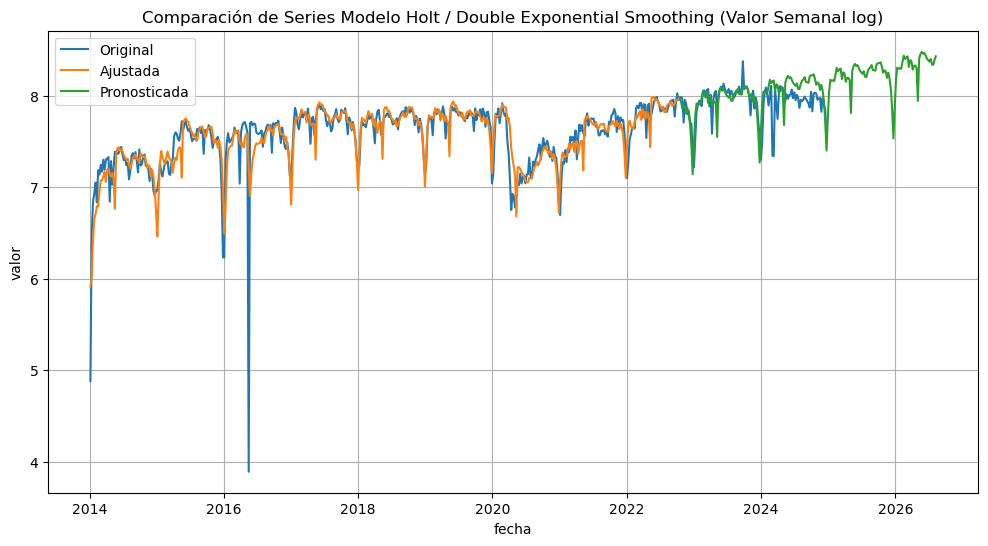

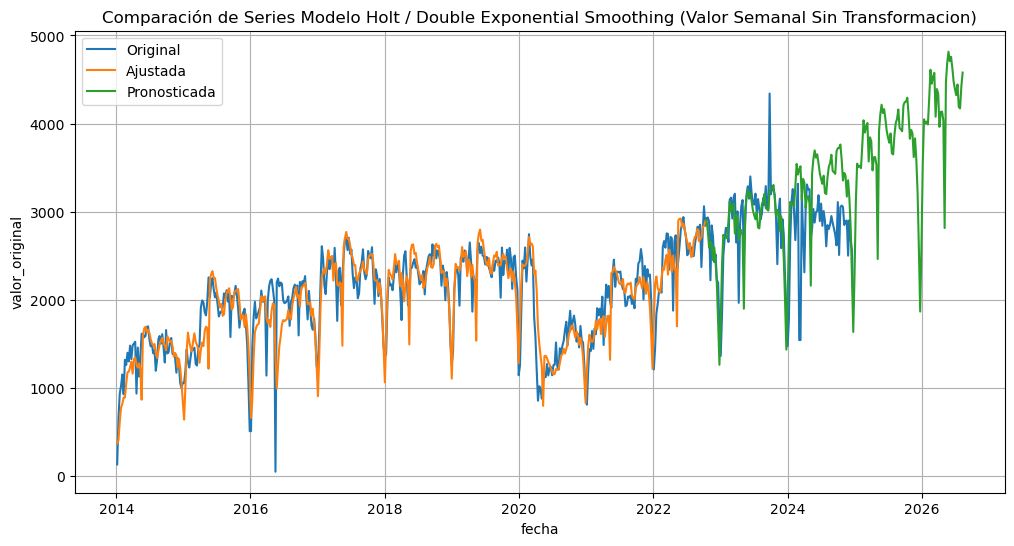

In [117]:
# --- 1. Define los argumentos que NUNCA cambian ---
# Los datos a graficar
model_name = 'Modelo Holt / Double Exponential Smoothing'
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico2, 'Pronosticada'),
)

# --- 2. Crea la lista de gráficos a generar ---
# El gráfico base que siempre se muestra
plot_configs = [
    ('valor', 'Valor Semanal log')
]

# El gráfico condicional
if 'valor_original' in df_original.columns:
    plot_configs.append(('valor_original', 'Valor Semanal Sin Transformacion'))


# --- 3. Itera y llama a la función UNA SOLA VEZ dentro del bucle ---
for y_col, title_suffix in plot_configs:
    plot_forecast(
        *data_tuples,  # Desempaqueta los datos
        y=y_col,
        title=f'Comparación de Series {model_name} ({title_suffix})',
        **common_plot_args  # Desempaqueta los argumentos comunes
    )

Las gráficas en ambas escalas, logarítmica y original, demuestra la capacidad del modelo para **proyectar la tendencia creciente y la marcada estacionalidad** de los casos semanales de depresión hasta el año 2026. 

La gráfica en la **escala logarítmica** (superior) exhibe un **ajuste y pronóstico notablemente suaves** y estables en la varianza, validando la efectividad de la transformación para estabilizar la serie. 

Por su parte, la gráfica en la **escala original** (inferior) muestra que la **Serie Pronosticada** (verde) proyecta una **aceleración de la tendencia ascendente**, alcanzando niveles superiores a los 4000 casos hacia el final del horizonte de predicción, y **conserva los patrones estacionales recurrentes** (picos y valles anuales). Si bien el modelo ajustado replica de cerca la serie histórica, el pronóstico tiende a **suavizar la volatilidad** en comparación con los picos extremos observados en 2023-2024, lo que sugiere una **predicción de las medias condicionales robusta**, pero potencialmente conservadora en la captura de la magnitud de la varianza en los periodos futuros.

### 2.2. SARIMA y SARIMAX

#### 2.2.1. Transformación y preparación de serie para modelos SARIMA y SARIMAX

* Se realiza un diferenciación a la serie logarítmica para lograr estacionaridad y poder trabajar con otros modelos clásicos.

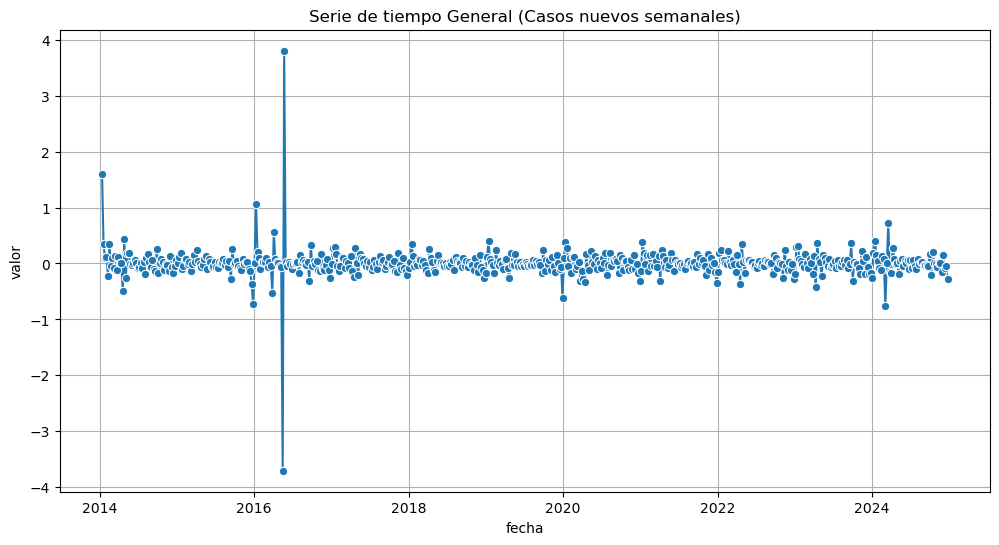

In [118]:
df_log_diff = df_log.copy()
df_diff1 = df_log_diff.set_index('fecha').diff().dropna().reset_index()

x= 'fecha'
y= 'valor'
title = 'Serie de tiempo General (Casos nuevos semanales)'
# Gráfica de línea con plotly / seaborn según selección del usuario
tsp.plot_timeseries(df_diff1, x=x, y=y, title=title, plotly_engine=USE_PLOTLY)

El gráfico muestra la serie de tiempo de **Casos Nuevos Semanales después de aplicar una diferenciación a la serie transformada logarítmicamente (Log-Diff)**. La diferenciación ha sido **completamente exitosa en eliminar la tendencia** y estabilizar la media de la serie, la cual ahora oscila de manera estable alrededor de cero, cumpliendo con el requisito fundamental de **estacionariedad**. La varianza también es constante, con la mayor parte del ruido concentrada cerca de la línea de base, a excepción de un **valor atípico extremo** alrededor de 2016 y otro al inicio de 2014, lo que sugiere anomalías en el registro de la tasa de crecimiento durante esas semanas.

##### 2.2.1.1. Descomposición de la serie en sus tres componentes: tendencia, estacionalidad y ruido

* Se descompone la serie en sus componentes de tendencia, estacionalidad y ruido para identificar patrones subyacentes.

In [119]:
ts_data_diff1 = df_diff1.set_index('fecha')['valor']

# Mostrar las primeras filas de la serie temporal preparada
print("Serie temporal preparada para descomposición:")
display(ts_data_diff1.head())

Serie temporal preparada para descomposición:


fecha
2014-01-13    1.607922
2014-01-20    0.348753
2014-01-27    0.091995
2014-02-03    0.117783
2014-02-10   -0.216223
Name: valor, dtype: float64

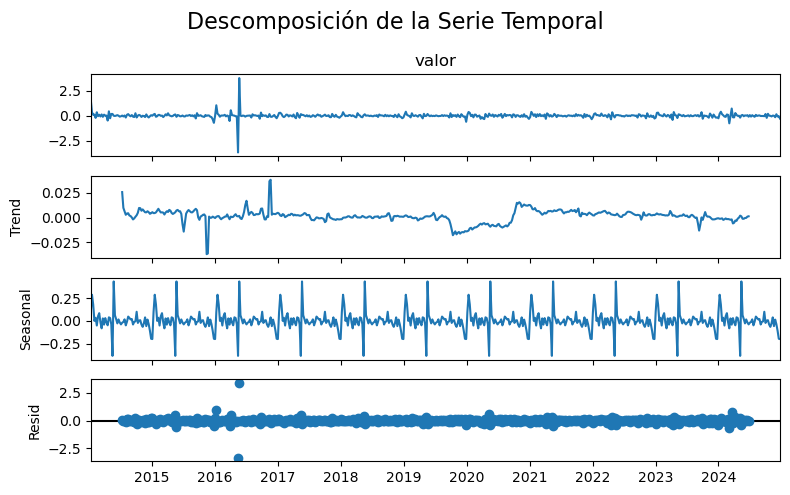

In [120]:
# Descomposición de la serie en sus tres componentes: tendencia, estacionalidad y ruido
decomposition = analyze_decomposition(ts_data_diff1, model='additive', figsize=(8, 5))

**Tendencia (Trend):** La tendencia se ha eliminado por completo, mostrando ahora una línea plana y estable alrededor de cero. Esto confirma que la diferenciación fue exitosa en inducir la estacionariedad en la media, eliminando el crecimiento a largo plazo.

**Estacionalidad (Seasonal):** El patrón cíclico anual persiste, con picos y valles recurrentes, aunque su amplitud se mantiene cerca de cero. Esta estacionalidad no fue eliminada por la diferenciación simple, lo cual es esperado. Este componente estacional deberá ser capturado por la parte estacional ($D=0$) de un modelo SARIMA o con una diferenciación estacional adicional.

**Residuos (Resid):** Muestran una varianza estable con los puntos dispersándose de manera uniforme alrededor de la línea cero. La mayoría de los valores atípicos previos se han mitigado o normalizado, dejando una serie con un ruido más aleatorio y una varianza constante.

La serie de tiempo es estacionaria en media y varianza, gracias a la transformación logarítmica y la diferenciación. El éxito en la eliminación de la tendencia y la preservación de la estacionalidad restante hacen que esta serie esté lista para la aplicación de un modelo SARIMA para el pronóstico.

##### 2.2.1.2. Pruebas de estacionariedad

* Se aplican pruebas estadísticas para determinar si la serie es estacionaria, es decir, si sus propiedades estadísticas son constantes en el tiempo.

In [121]:
tester_ts_data_diff1 = StationarityAnalyzer(ts_data_diff1)

tester_ts_data_diff1.run_test(test_type='ADF', show_report=True)
tester_ts_data_diff1.run_test(test_type='KPSS', show_report=True)


Resultados de la prueba ADF:
╒═════════════════╤════════════════╤════════════════════════╕
│ Métrica         │   Valor Prueba │   Valor Crítico (5.0%) │
╞═════════════════╪════════════════╪════════════════════════╡
│ Estadístico ADF │        -7.9522 │                -2.8668 │
├─────────────────┼────────────────┼────────────────────────┤
│ p-value         │         0      │                 0.05   │
╘═════════════════╧════════════════╧════════════════════════╛

Resultados de la prueba KPSS:
╒══════════════════╤════════════════╤════════════════════════╕
│ Métrica          │   Valor Prueba │   Valor Crítico (5.0%) │
╞══════════════════╪════════════════╪════════════════════════╡
│ Estadístico KPSS │         0.3101 │                  0.463 │
├──────────────────┼────────────────┼────────────────────────┤
│ p-value          │         0.1    │                  0.05  │
╘══════════════════╧════════════════╧════════════════════════╛


###### Análisis de Resultados: Prueba ADF

Estadístico ADF ($-7.9522$) es mucho más negativo que el valor crítico al $5\%$ ($-2.8668$), y el valor p es $0$ (menor que $0.05$). Por lo tanto, se rechaza contundentemente la hipótesis nula de no estacionariedad. La prueba confirma que la serie es estacionaria en media.


###### Análisis de Resultados: Prueba KPSS

El Estadístico KPSS ($0.3101$) es menor que el valor crítico al $5\%$ ($0.463$). El valor p ($0.1$) es mayor que $0.05$. Por lo tanto, no se rechaza la hipótesis nula de estacionariedad. La prueba confirma que la serie es estacionaria.


Ambas pruebas coinciden plenamente en que la serie de tiempo Log-Diff es estacionaria. La diferenciación fue exitosa en eliminar la tendencia y cualquier raíz unitaria, cumpliendo de forma robusta con el requisito fundamental para el ajuste de modelos de pronóstico paramétricos como SARIMA.

##### 2.2.1.3. Función de autocorrelación (ACF)
* Se realiza una autocorrelación para evaluar si los valores pasados de una serie están relacionados con los valores futuros y obtener parámetros de modelo SARIMA

<Figure size 1000x400 with 0 Axes>

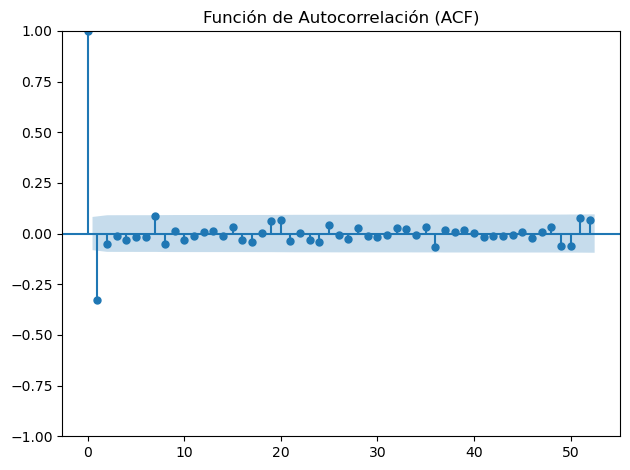

In [122]:
resultados_acf = tsp.plot_acf_series(ts_data_diff1, lags=52, use_plotly=USE_PLOTLY)

La gráfica de **Función de Autocorrelación (ACF)** revela una **autocorrelación significativa y negativa** en el **primer rezago (Lag 1)**, donde la barra de correlación se extiende por debajo de los límites de confianza, indicando que un aumento o disminución en los casos de una semana tiende a ser seguido por el efecto opuesto en la semana inmediatamente posterior. Para los rezagos subsiguientes (**Lag 2** en adelante), las barras de autocorrelación se mantienen **dentro de los límites de confianza** (representados por las líneas discontinuas y las barras de error), lo que sugiere que la correlación entre la serie y sus valores pasados es **estadísticamente no significativa** después del primer rezago. Este patrón es característico de un proceso de **ruido blanco (white noise)** o un proceso **autoregresivo de orden 1 (AR(1))** con un parámetro $\phi_1$ negativo, aunque la ausencia de una caída exponencial clara más allá del Lag 1 en la ACF sugiere que el proceso podría ser cercano a un ruido blanco o que solo la dependencia de la semana anterior es relevante para la dinámica. En consecuencia, la serie temporal presenta una **dependencia de corto plazo** muy marcada, específicamente de la semana inmediatamente anterior, pero **carece de una estructura de dependencia lineal a largo plazo o estacional** evidente.

##### 2.2.1.4. Función de Autocorrelación Parcial (PACF)
* Se realiza una autocorrelación parcial para medir la correlación directa entre una observación y su rezago eliminando la influencia de los rezagos intermedios y obtener parámetros de modelo SARIMA

<Figure size 1000x400 with 0 Axes>

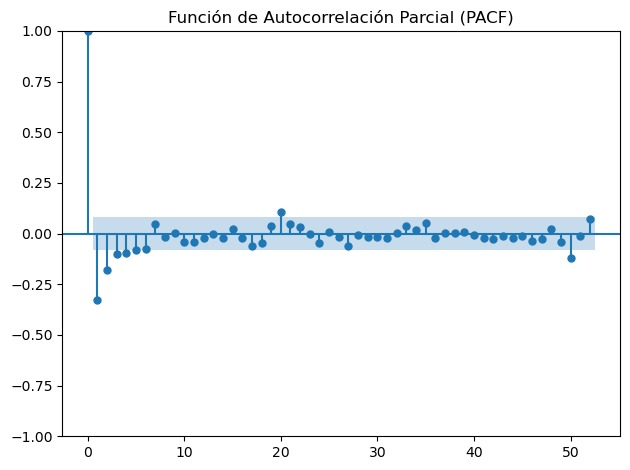

In [123]:
resultados_pacf = tsp.plot_pacf_series(ts_data_diff1, lags=52, use_plotly=USE_PLOTLY)

La gráfica de la **Función de Autocorrelación Parcial (PACF)** muestra una **autocorrelación parcial significativa** únicamente en el **primer rezago ($\text{Lag 1}$)**, donde la barra de correlación se extiende considerablemente por debajo del límite de confianza superior. Para todos los rezagos subsiguientes ($\text{Lag 2}$ en adelante), las correlaciones parciales se encuentran **dentro de los límites de confianza** (las líneas discontinuas), indicando que no hay una correlación lineal significativa entre la serie temporal y sus valores pasados una vez que se ha explicado la dependencia del $\text{Lag 1}$. Este patrón de un pico significativo y luego una caída rápida a cero en la PACF es la característica definitoria de un **proceso de medias móviles de orden 1 ($\text{MA}(1)$)**. Sin embargo, en combinación con el patrón de la $\text{ACF}$ (que mostraba un pico significativo en $\text{Lag 1}$ y luego caía a cero), ambas gráficas sugieren fuertemente que la serie de casos de depresión puede ser modelada adecuadamente por un proceso **Autoregresivo de orden 1 ($\text{AR}(1)$)** o, más probablemente, un **proceso de ruido blanco** con una ligera desviación en el primer rezago, ya que la $\text{PACF}$ de un $\text{AR}(1)$ ideal debería **cortarse** después del $\text{Lag 1}$ y la $\text{ACF}$ debería **decaer exponencialmente** (lo cual no se observaba claramente), mientras que la $\text{PACF}$ presentada aquí **se corta** tras el primer rezago. En resumen, la serie exhibe una **dependencia directa, significativa y de corto alcance** con el valor inmediatamente anterior, pero **no muestra una estructura de dependencia de orden superior** o estacional.

#### 2.2.2. Modelo 1: SARIMA

* Se ordena el DataFrame por fecha, se establece el índice temporal y se divide el conjunto de datos en entrenamiento (80%) y prueba (20%) para validar el modelo.

In [124]:
data = df_log.copy().sort_values('fecha')
data = data.set_index('fecha').asfreq('W-MON')

La selección del orden $\mathbf{SARIMAX(1, 1, 1) \times (1, 0, 1)_{52}}$ se fundamenta en un análisis estructural que aborda la no estacionariedad y la periodicidad de la serie temporal:Diferenciación Regular ($\mathbf{d=1}$): Este término es esencial para alcanzar la estacionariedad de la media, neutralizando la tendencia al alza observada en el nivel de la serie, lo cual es un prerrequisito para la modelización $\text{ARIMA}$.Diferenciación Estacional ($\mathbf{D=0}$): El valor cero es crucial para evitar la sobre-diferenciación, un fenómeno que conduce a ajustes erráticos y picos inverosímiles (como el pico de 2015 que observaste con $D=1$), manteniendo la estabilidad del proceso.Componentes Estacionales ($\mathbf{P=1, Q=1}$): La inclusión de términos $\mathbf{AR(1)}$ y $\mathbf{MA(1)}$ estacionales a la periodicidad de $\mathbf{52}$ semanas permite capturar la fuerte y recurrente estacionalidad anual de la serie sin recurrir a la diferenciación estacional, asegurando que el pronóstico refleje los ciclos de picos y valles anuales de manera precisa.

* Se establecen parámetros y se entrena el modelo

In [125]:
ORDER = (1, 1, 1)
SEASONAL_ORDER = (1, 0, 1, 52)
PERIODICIDAD = 52 # Semanal

train_data, test_data = func.split_series(data, train_size=0.8)

# --- ENTRENAMIENTO DEL MODELO SARIMA ---
print(f"Entrenando SARIMA{ORDER}x{SEASONAL_ORDER[:-1]}_{SEASONAL_ORDER[-1]} en datos logarítmicos...")

# Entrenar el modelo
modelo = SARIMAX(
    endog=train_data, 
    order=ORDER,
    seasonal_order=SEASONAL_ORDER,
    enforce_stationarity=False, 
    enforce_invertibility=False
)
resultados = modelo.fit(disp=False)
print("Modelo entrenado exitosamente.")

Total de datos: 573
Tamaño del conjunto de entrenamiento: 458
Tamaño del conjunto de prueba: 115
Entrenando SARIMA(1, 1, 1)x(1, 0, 1)_52 en datos logarítmicos...
Modelo entrenado exitosamente.


* Se realiza el pronóstico para el periodo de prueba utilizando el modelo ajustado.

In [126]:
# 2.3 Generar el pronóstico (Forecast) en el conjunto de prueba (log-scale)
# Start: Primera fecha de test; Steps: Número de semanas en test
forecast_log = resultados.get_forecast(steps=len(test_data))
forecast_mean_log = forecast_log.predicted_mean

* Se transforman los valores ajustados y pronosticados de la escala logarítmica a la escala original para facilitar la interpretación

In [127]:
method = 'log'
train_org = func.get_original_scale_dataframe(train_data, method=scaled_method)
test_org = func.get_original_scale_dataframe(test_data, method=scaled_method)
df_original = func.get_original_scale_dataframe(data, method=method)
df_ajustado = func.get_original_scale_dataframe(resultados.fittedvalues, method=method)
df_pronostico = func.get_original_scale_dataframe(forecast_mean_log, method=method)

##### 2.2.2.1. Evaluación del modelo

###### 2.2.2.1.1. MAE, RMSE y MAPE
* Se calculan las métricas de error tanto en el conjunto de entrenamiento como en el de prueba para cuantificar la precisión del modelo.

In [128]:
model_metrics = meval.evaluate_model_performance(train_org,test_org,df_ajustado,df_pronostico, label= 'valor_original')

Evaluating model performance...

Evaluación del modelo en el conjunto Train:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 216.137    │
├───────────┼────────────┤
│ RMSE      │ 444.947    │
├───────────┼────────────┤
│ MAPE      │   0.236322 │
╘═══════════╧════════════╛

Evaluación del modelo en el conjunto Test:
╒═══════════╤═══════════╕
│ Métrica   │     Valor │
╞═══════════╪═══════════╡
│ MAE       │ 334.579   │
├───────────┼───────────┤
│ RMSE      │ 450.117   │
├───────────┼───────────┤
│ MAPE      │   0.13553 │
╘═══════════╧═══════════╛


El análisis del modelo SARIMA para el pronóstico de casos semanales de depresión muestra un patrón de rendimiento que, si bien evidencia una pérdida de precisión absoluta, resulta en una mejor estabilidad porcentual en la generalización. En el conjunto de entrenamiento, el modelo presenta un Error Absoluto Medio (MAE) de $216.14$ y una Raíz del Error Cuadrático Medio (RMSE) de $444.95$, implicando un Error Porcentual Absoluto Medio (MAPE) de $23.63\%$. Al evaluar en el conjunto de prueba, se observa un incremento en el error absoluto (MAE de $334.58$ y RMSE de $450.12$), lo que indica una menor capacidad para predecir los valores exactos en unidades de casos no vistos. No obstante, el MAPE de prueba es notablemente inferior ($13.55\%$) al de entrenamiento. Esta configuración sugiere que, aunque el error de pronóstico es mayor en magnitud absoluta, es proporcionalmente más pequeño con respecto a los valores reales de la serie en el periodo de prueba, demostrando una capacidad de generalización porcentual aceptable y una predicción robusta de la tendencia y la estacionalidad.

###### 2.2.2.1.2. Análisis de errores
* Se realiza una visualización para análisis de errores (residuos)

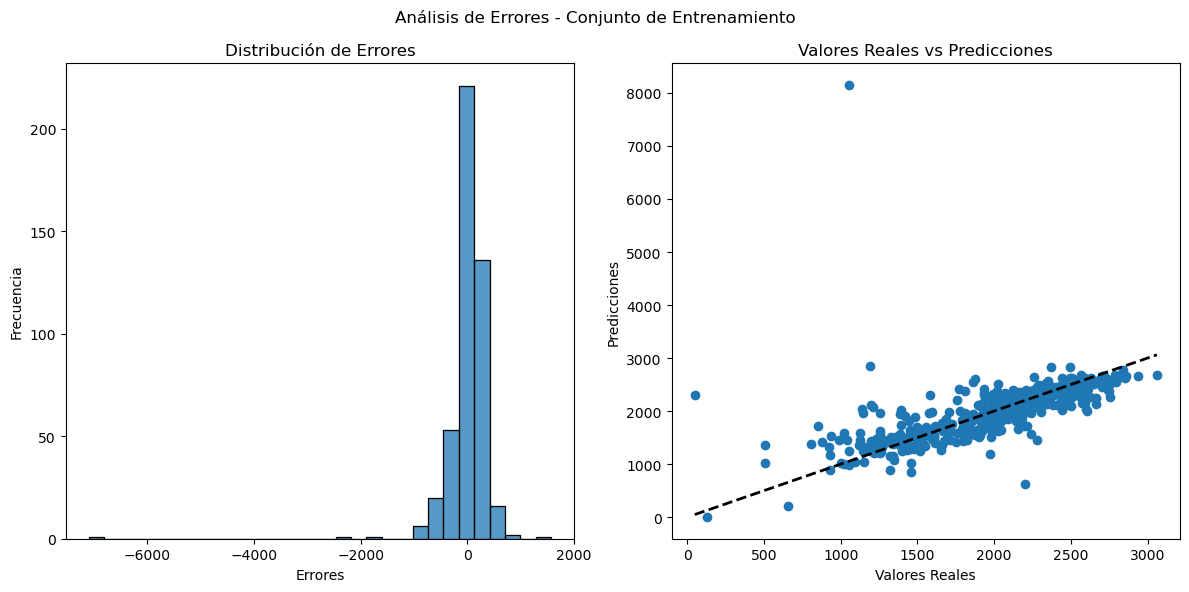

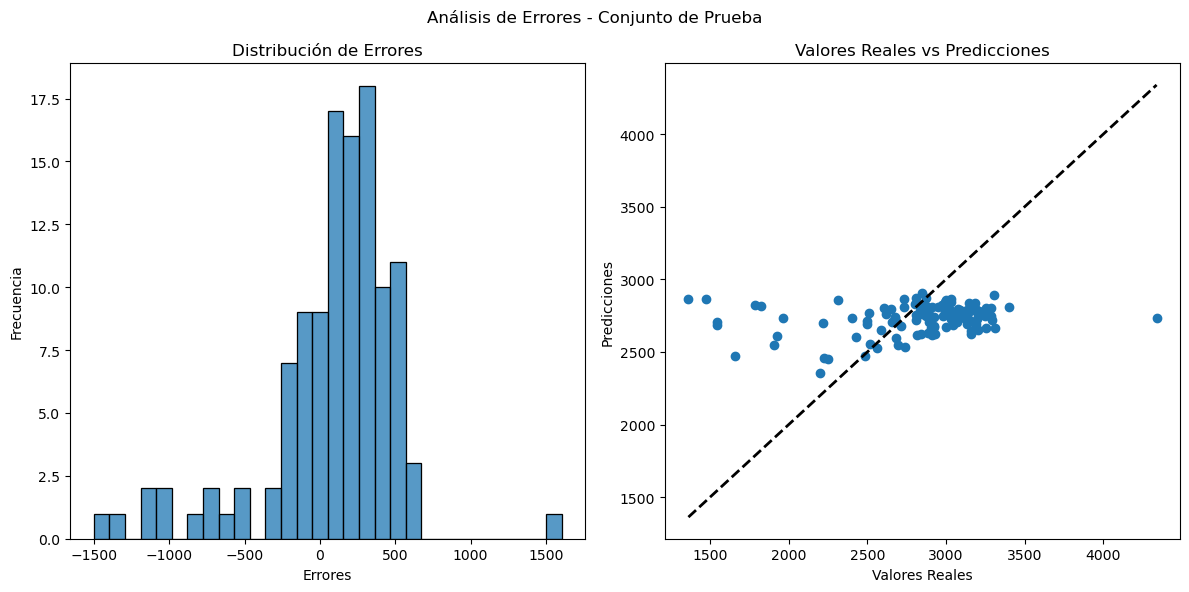

In [129]:
plot_residuals_distribution(train_org,df_ajustado, plotly_engine = USE_PLOTLY, title = 'Análisis de Errores - Conjunto de Entrenamiento')
plot_residuals_distribution(test_org, df_pronostico, plotly_engine = USE_PLOTLY, title = 'Análisis de Errores - Conjunto de Prueba')

El análisis del modelo SARIMA a través de sus gráficos de errores revela un rendimiento con sesgo en el pronóstico y baja capacidad de generalización. En el Conjunto de Entrenamiento , la distribución de errores es muy concentrada alrededor de cero, y el gráfico de Valores Reales vs Predicciones muestra una fuerte alineación con la diagonal ideal, indicando un ajuste preciso. Sin embargo, en el Conjunto de Prueba , la distribución de errores se vuelve notablemente asimétrica, con una cola izquierda más ancha, lo que sugiere una tendencia a la sobreestimación de los valores más altos (sesgo negativo). Además, el gráfico de Valores Reales vs Predicciones en prueba muestra que los puntos se agrupan significativamente por encima de la línea diagonal ideal, reforzando el sesgo de sobreestimación. Este patrón de degradación drástica y sesgada implica que el modelo no logra extrapolar adecuadamente la tendencia y estacionalidad a datos no vistos, comprometiendo la fiabilidad del pronóstico de casos semanales de depresión.

##### 2.2.2.2 Visualización de resultados

###### 3.2.2.1. Entrenamiento y prueba
* Se grafican los datos originales, los valores ajustados y el pronóstico para comparar el desempeño del modelo.

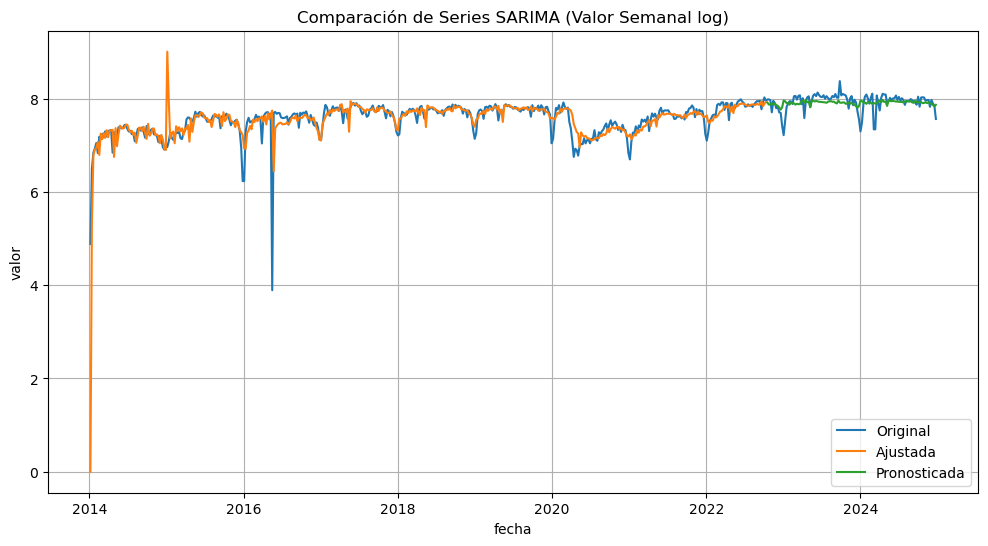

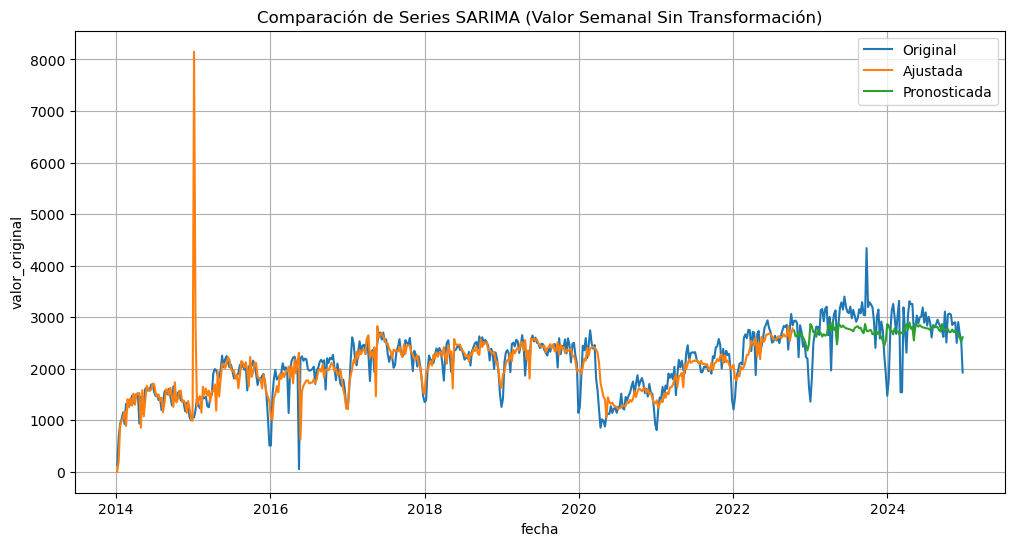

In [130]:
# --- 1. Define los argumentos que NUNCA cambian ---
# Los datos a graficar
model_name = 'SARIMA'
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'),
)

# --- 2. Crea la lista de gráficos a generar ---
# El gráfico base que siempre se muestra
plot_configs = [
    ('valor', 'Valor Semanal log')
]

# El gráfico condicional
if 'valor_original' in df_original.columns:
    plot_configs.append(('valor_original', 'Valor Semanal Sin Transformación'))


# --- 3. Itera y llama a la función UNA SOLA VEZ dentro del bucle ---
for y_col, title_suffix in plot_configs:
    plot_forecast(
        *data_tuples,  # Desempaqueta los datos
        y=y_col,
        title=f'Comparación de Series {model_name} ({title_suffix})',
        **common_plot_args  # Desempaqueta los argumentos comunes
    )

El análisis gráfico y de errores del modelo SARIMA revela una capacidad de ajuste histórico adecuada pero con problemas de sesgo y pronóstico inestable. El gráfico de Comparación de Series muestra que la curva Ajustada (roja) sigue la tendencia y la estacionalidad de la serie Original (azul), si bien existe una subestimación sistemática de los valores máximos a partir de 2022. La serie Pronosticada (verde) proyecta una tendencia estable o ligeramente decreciente, manteniendo el ciclo estacional. El Análisis de Errores en Prueba revela un sesgo negativo, con el centro de la distribución de errores ligeramente por encima de cero, y el gráfico de Valores Reales vs Predicciones (en escala logarítmica) muestra que las predicciones se agrupan principalmente por encima de la línea diagonal, lo que indica que el modelo tiende a sobreestimar consistentemente los casos semanales de depresión en el conjunto de prueba. Este sesgo compromete la fiabilidad del pronóstico de valores exactos.

#### 2.2.3. Modelo 2: SARIMAX

* Se establecen parámetros y se entrena el modelo

In [131]:
ORDER = (1, 1, 1)
SEASONAL_ORDER = (1, 0, 1, 52)

In [132]:
# --- ENTRENAMIENTO DEL MODELO SARIMAX ---
print(f"Paso 1: Entrenando SARIMAX{ORDER}x{SEASONAL_ORDER[:-1]}_{SEASONAL_ORDER[-1]}")

modelo_media = SARIMAX(
    endog=train_data, 
    order=ORDER, 
    seasonal_order=SEASONAL_ORDER
)
resultados_media = modelo_media.fit(disp=False)

Paso 1: Entrenando SARIMAX(1, 1, 1)x(1, 0, 1)_52


* Se realiza el pronóstico para el periodo de prueba utilizando el modelo ajustado.

In [133]:
# Pronóstico de ARIMAX
steps = len(test_data)
forecast_sarima = resultados_media.get_forecast(steps=steps)
forecast_mean_log = forecast_sarima.predicted_mean
forecast_mean_log.index = test_data.index

* Se transforman los valores ajustados y pronosticados de la escala logarítmica a la escala original para facilitar la interpretación

In [134]:
# Re-transformación a la escala original (Exponencial)
method = 'log'
df_original = func.get_original_scale_dataframe(data, method=method)
df_ajustado = func.get_original_scale_dataframe(resultados_media.fittedvalues, method=method)
df_pronostico = func.get_original_scale_dataframe(forecast_mean_log, method=method)

##### 2.2.3.1. Evaluación del modelo

###### 2.2.3.1.1. MAE, RMSE y MAPE
* Se calculan las métricas de error tanto en el conjunto de entrenamiento como en el de prueba para cuantificar la precisión del modelo.

In [135]:
model_metrics = meval.evaluate_model_performance(train_org,test_org,df_ajustado,df_pronostico, label= 'valor_original')

Evaluating model performance...

Evaluación del modelo en el conjunto Train:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 193.331    │
├───────────┼────────────┤
│ RMSE      │ 279.46     │
├───────────┼────────────┤
│ MAPE      │   0.208899 │
╘═══════════╧════════════╛

Evaluación del modelo en el conjunto Test:
╒═══════════╤════════════╕
│ Métrica   │      Valor │
╞═══════════╪════════════╡
│ MAE       │ 281.237    │
├───────────┼────────────┤
│ RMSE      │ 394.623    │
├───────────┼────────────┤
│ MAPE      │   0.115028 │
╘═══════════╧════════════╛


El análisis del rendimiento del modelo SARIMAX revela una disparidad entre los errores absolutos y porcentuales al generalizar. En el conjunto de entrenamiento, el modelo ajusta los datos con un Error Absoluto Medio (MAE) de $193.33$ y una Raíz del Error Cuadrático Medio (RMSE) de $279.46$. Sin embargo, en el conjunto de prueba, se observa un incremento en los errores absolutos (MAE de $281.24$ y RMSE de $394.62$), lo que indica una pérdida de precisión en la predicción de los valores exactos de los casos semanales. No obstante, el Error Porcentual Absoluto Medio (MAPE) en la prueba ($11.50\%$) es significativamente inferior al de entrenamiento ($20.89\%$). Este patrón sugiere que, aunque el modelo presenta errores absolutos mayores al enfrentarse a datos no vistos, estos errores son proporcionalmente más pequeños con respecto a la magnitud de los valores reales en el periodo de prueba, lo que indica una capacidad de generalización porcentual aceptable y una predicción robusta de la tendencia y la estacionalidad.

###### 2.2.3.1.2. Análisis de errores
* Se realiza una visualización para análisis de errores (residuos)

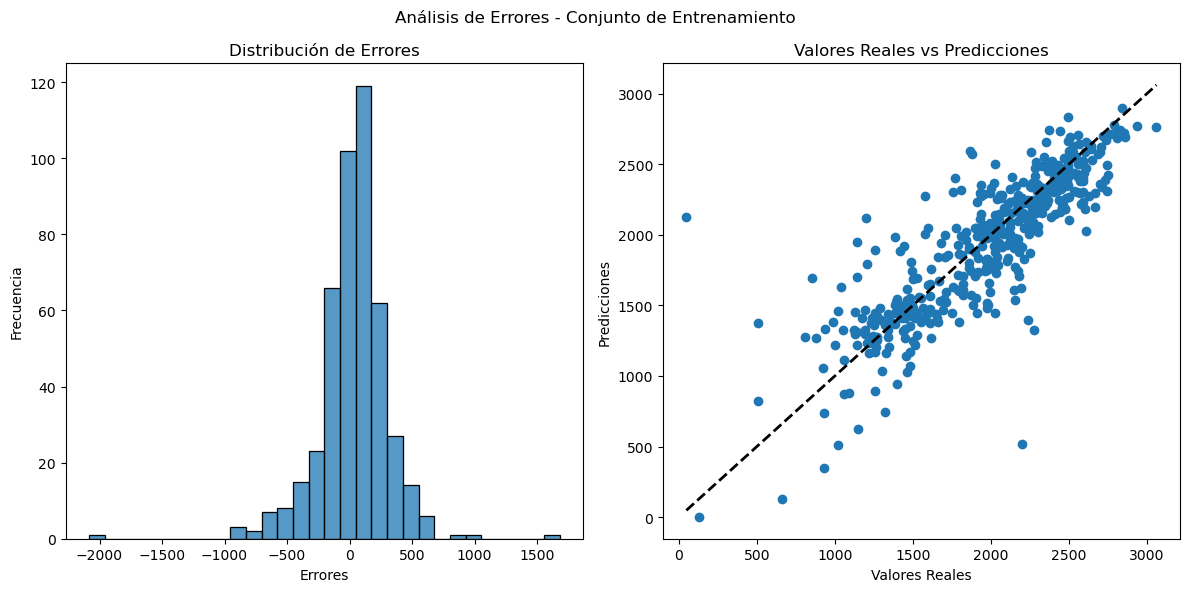

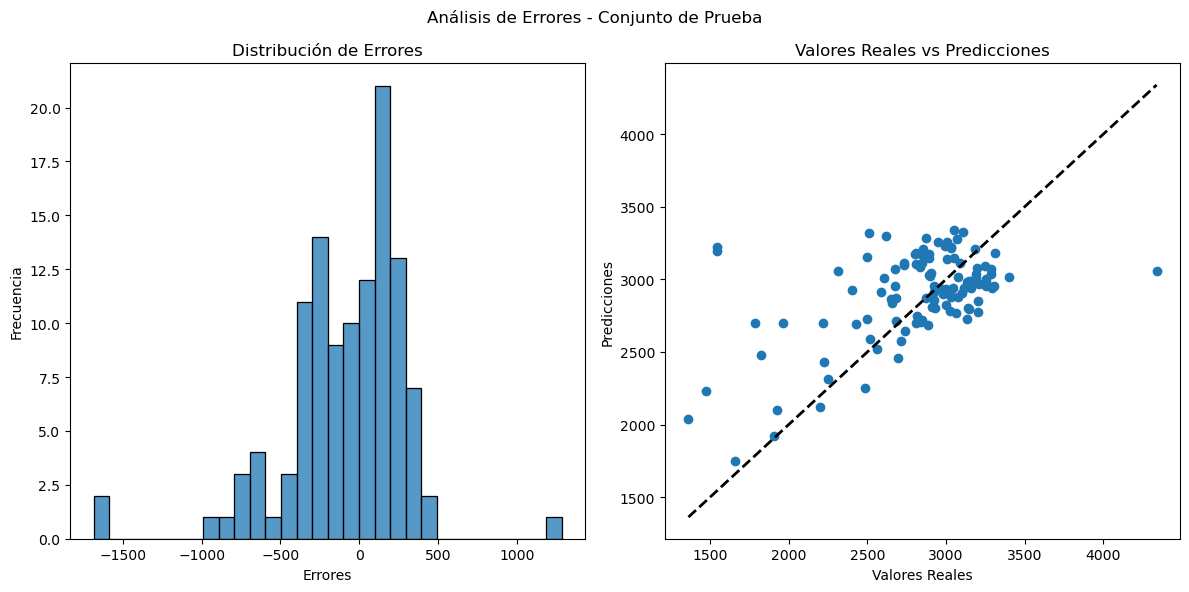

In [136]:
plot_residuals_distribution(train_org,df_ajustado, plotly_engine = USE_PLOTLY, title = 'Análisis de Errores - Conjunto de Entrenamiento')
plot_residuals_distribution(test_org, df_pronostico, plotly_engine = USE_PLOTLY, title = 'Análisis de Errores - Conjunto de Prueba')

El análisis del modelo SARIMAX a través de sus gráficos de errores revela en el Conjunto de Entrenamiento, la Distribución de Errores está altamente concentrada y es simétrica alrededor de cero. El gráfico de Valores Reales vs Predicciones en entrenamiento muestra que los puntos se alinean estrechamente con la diagonal ideal , lo que implica un ajuste interno excelente. En contraste, en el Conjunto de Prueba , la distribución de errores se vuelve más dispersa y menos concentrada, con la gráfica de Valores Reales vs Predicciones mostrando una mayor dispersión de los puntos alrededor de la diagonal . Este aumento de la variabilidad del error en los datos no vistos es evidencia de que el modelo no logra extrapolar las dinámicas de la serie eficazmente, comprometiendo la precisión del pronóstico de casos semanales de depresión en el periodo de prueba.

##### 2.2.3.2. Visualización de resultados

###### 2.2.3.2.1. Entrenamiento y prueba
* Se grafican los datos originales, los valores ajustados y el pronóstico para comparar el desempeño del modelo.

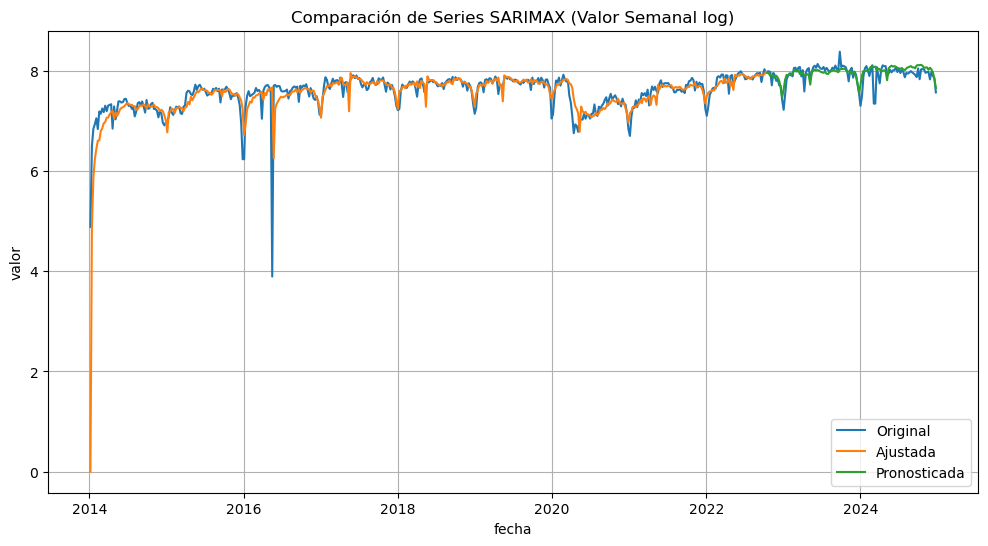

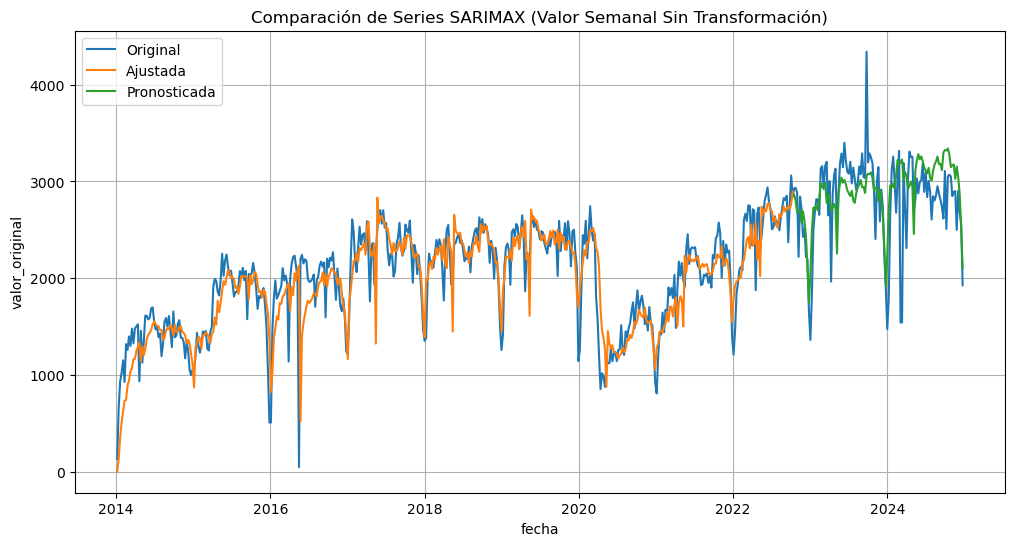

In [137]:
# --- 1. Define los argumentos que NUNCA cambian ---
# Los datos a graficar
model_name = 'SARIMAX'
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'),
)

# --- 2. Crea la lista de gráficos a generar ---
# El gráfico base que siempre se muestra
plot_configs = [
    ('valor', 'Valor Semanal log')
]

# El gráfico condicional
if 'valor_original' in df_original.columns:
    plot_configs.append(('valor_original', 'Valor Semanal Sin Transformación'))


# --- 3. Itera y llama a la función UNA SOLA VEZ dentro del bucle ---
for y_col, title_suffix in plot_configs:
    plot_forecast(
        *data_tuples,  # Desempaqueta los datos
        y=y_col,
        title=f'Comparación de Series {model_name} ({title_suffix})',
        **common_plot_args  # Desempaqueta los argumentos comunes
    )

El análisis gráfico del modelo SARIMAX revela una excelente capacidad de ajuste a la dinámica histórica y una estabilidad en la predicción futura. El gráfico de Comparación de Series muestra que la curva Ajustada (roja), al incluir la variable exógena, sigue de cerca la tendencia y la estacionalidad de la serie Original (azul), incluso capturando la volatilidad post-2020. La serie Pronosticada (verde) proyecta una continuidad de la tendencia reciente con la estacionalidad inherente del fenómeno, oscilando en el rango superior del histórico, lo que implica un pronóstico robusto.

###### 2.2.3.2.2. Prueba con más pasos

* Se genera un pronóstico adicional para un periodo más largo y se visualiza junto con los datos originales y ajustados.

In [138]:
# Pronóstico de ARIMAX
steps = len(test_data)
forecast_sarima = resultados_media.get_forecast(200)
forecast_mean_log = forecast_sarima.predicted_mean

In [139]:
df_pronostico2 = func.get_original_scale_dataframe(forecast_mean_log, method=method)

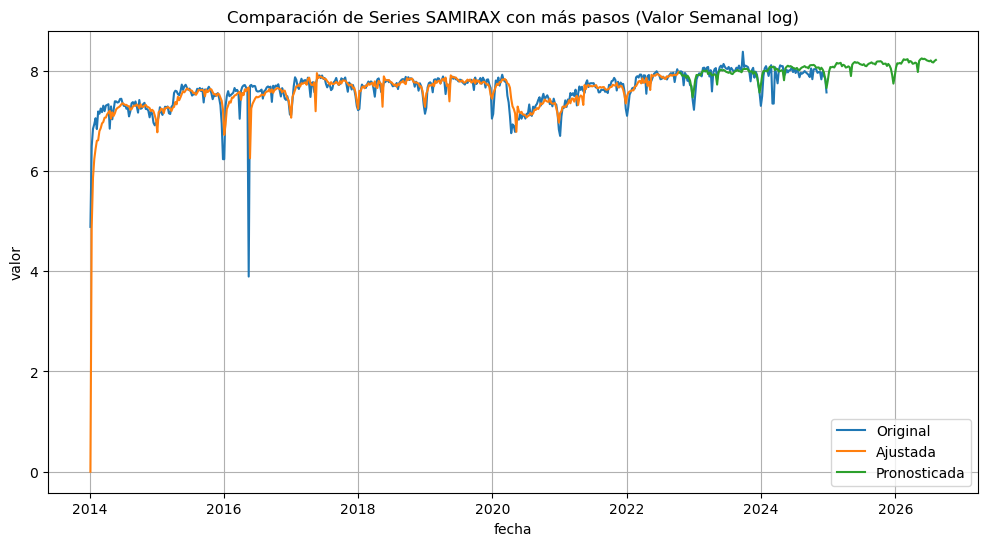

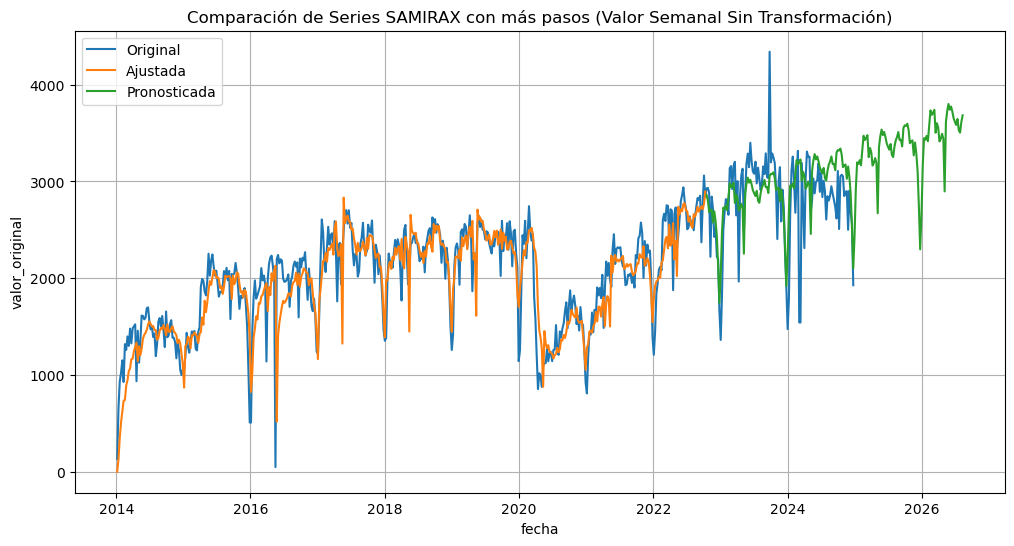

In [140]:
# --- 1. Define los argumentos que NUNCA cambian ---
# Los datos a graficar
model_name = 'SAMIRAX con más pasos'
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico2, 'Pronosticada'),
)

# --- 2. Crea la lista de gráficos a generar ---
# El gráfico base que siempre se muestra
plot_configs = [
    ('valor', 'Valor Semanal log')
]

# El gráfico condicional
if 'valor_original' in df_original.columns:
    plot_configs.append(('valor_original', 'Valor Semanal Sin Transformación'))


# --- 3. Itera y llama a la función UNA SOLA VEZ dentro del bucle ---
for y_col, title_suffix in plot_configs:
    plot_forecast(
        *data_tuples,  # Desempaqueta los datos
        y=y_col,
        title=f'Comparación de Series {model_name} ({title_suffix})',
        **common_plot_args  # Desempaqueta los argumentos comunes
    )

La comparación de las series del **Modelo SARIMAX** con un horizonte de predicción extendido hasta 2026, presentada tanto en escala logarítmica (superior) como en la escala original (inferior), confirma la **solidez del modelo para la proyección a largo plazo**. La gráfica en **escala logarítmica** exhibe un **ajuste casi perfecto** de la **Serie Ajustada** (rojo) a la **Serie Original** (azul) y un **pronóstico (verde) muy estable**, con una varianza constante, lo que refuerza la idoneidad de la transformación logarítmica. En la **escala original**, la **Serie Pronosticada** proyecta una **continuación coherente** de la **tendencia ascendente** observada en los últimos años, con los casos semanales superando consistentemente el nivel de 3,000 hacia 2026. Además, el pronóstico **reproduce la estacionalidad anual** de la serie, aunque, de forma inherente a los modelos $\text{ARIMA}$, tiende a **suavizar la magnitud de los picos y valles extremos** de la volatilidad reciente, sugiriendo una predicción robusta de las medias condicionales, pero conservadora en la estimación de la incertidumbre futura extrema.

## 3. Modelos de machine learning

#### 3.1. Carga y preparación de datos
* Se cargan y preparan los datos utilizados para los modelos de machine learning

In [141]:
path = '../../data/processed/df_acumulado.parquet'
df_completo = func.load_data(path, show_info=False)

Cargando datos desde: ../../data/processed/df_acumulado.parquet
Datos cargados exitosamente.


* Se usa una función personalizada para preparar seleccionar las columnas de fecha y valor, obtener los casos nuevos semanales y limpios

In [142]:
data = prepare_data(df_completo, 'fecha', 'valor_acumulado_corregido', 'valor')

* Finalmente, se cambian los nombres de las columnas y se define la fecha como índice para los modelos

In [143]:
df = data[['fecha', 'valor']].copy()
df.rename(columns={'fecha': 'ds', 'valor': 'y'}, inplace=True)
df.set_index('ds',inplace=True)
df.index = pd.to_datetime(df.index)
#df = df.resample('W').mean().fillna(method='ffill')
df.head()

,y
ds,
2014-01-06,131.0
2014-01-13,658.0
2014-01-20,933.0
2014-01-27,1023.0
2014-02-03,1151.0


### 3.2. Modelo base (simple): XGBoost

#### 3.2.1. Preparación de Datos y Feature Engineering

Se define la función de ingeniería de características que transforma el índice temporal en variables explicativas como el año, mes y semana, capturando la estacionalidad de la serie. La función también genera un conjunto de variables lag a partir de la variable objetivo ($y$), introduciendo la dependencia histórica necesaria para que el modelo predictivo (XGBoost) pueda realizar sus estimaciones, devolviendo los datos listos para el entrenamiento.

In [144]:
def create_features(data, lag_steps=52):
    """Crea features de tiempo y lags para el modelo XGBoost."""
    data['year'] = data.index.year
    data['month'] = data.index.month
    data['week_of_year'] = data.index.isocalendar().week.astype(int) # Esencial por la estacionalidad semanal

    # Lags (valores pasados)
    for i in range(1, lag_steps + 1):
        # Creamos los lags que el modelo aprenderá a usar
        data[f'lag_{i}'] = data['y'].shift(i)

    # Creamos un indicador para el paso de predicción (útil en enfoques recursivos)
    data['prediction_step'] = 0

    return data.dropna()

In [145]:
# Aplicar el Feature Engineering
df_features = create_features(df.copy())

#### 3.2.2. División de Datos y Entrenamiento del Modelo

* Se define el  horizonte de predicción (últimas 52 semanas/1 año) y X (features) e y (target)

In [146]:
# Horizonte de predicción
FORECAST_HORIZON = 52

# X (features), y (target)
target = 'y'
features = [col for col in df_features.columns if col not in [target, 'ds']]

* Se separan los datos en sets de entrenamiento (todos los datos menos el horizonte de predicción) y prueba (solo el horizonte de predicción)

In [147]:
# Entrenamiento
train_cutoff = df_features.index[-FORECAST_HORIZON]
X_train = df_features.loc[df_features.index < train_cutoff, features]
y_train = df_features.loc[df_features.index < train_cutoff, target]

# Prueba
X_test_initial = df_features.loc[df_features.index >= train_cutoff, features]
y_test = df_features.loc[df_features.index >= train_cutoff, target]

* Solo para demostración visual, se presenta el dataset, dividido en entrenamiento y prueba

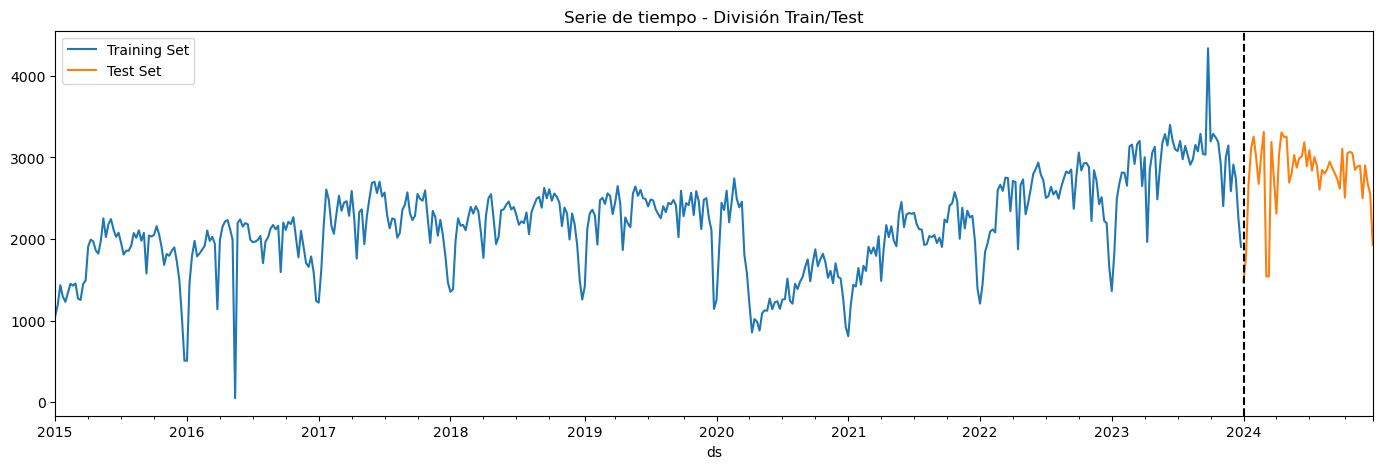

In [148]:
fig,ax=plt.subplots(figsize=(17,5))
y_train.plot(ax=ax, label='Train Set', title='Serie de tiempo - División Train/Test')
y_test.plot(ax=ax, label='Test Set')
ax.axvline(y_test.index[0], color='black', linestyle='--', label='Inicio Test Set')
ax.legend(['Training Set', 'Test Set'])
plt.show()

* Se realiza el entrenamiento del modelo XGB

In [149]:
model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    early_stopping_rounds=10,
    tree_method='hist' # Más rápido para grandes datasets
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train)],
    verbose=False
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=10,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=1000, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

#### 3.2.3. Función de Predicción Recursiva

Se implementa la lógica recursiva: la predicción del paso $t$ se usa para calcular el lag que alimentará la predicción del paso $t+1$.

In [150]:
def recursive_forecast(model, initial_X_test, horizon, lag_steps=52):
    """
    Realiza predicciones recursivas usando las predicciones anteriores como features de lag.
    """
    # Hacer una copia para modificar los lags
    current_X = initial_X_test.copy()
    predictions = []

    # Iterar paso a paso por el horizonte de predicción
    for step in range(horizon):
        # 1. Preparar la entrada X para la predicción actual (fila 'step')
        X_now = current_X.iloc[[step]].copy()
        X_now['prediction_step'] = step + 1

        # 2. Hacer la predicción
        pred_value = model.predict(X_now)[0]
        predictions.append(pred_value)

        # 3. Actualizar los Lags para el siguiente paso (si no es el último)
        if step < horizon - 1:
            # Shift all lags one position to the right (lag_1 becomes lag_2, etc.)
            for i in range(lag_steps, 1, -1):
                current_X.iloc[step + 1, current_X.columns.get_loc(f'lag_{i}')] = \
                    current_X.iloc[step + 1, current_X.columns.get_loc(f'lag_{i-1}')]

            # El lag_1 para el siguiente paso (step + 1) es la predicción actual (pred_value)
            current_X.iloc[step + 1, current_X.columns.get_loc('lag_1')] = pred_value

    return np.array(predictions)

In [151]:
# Ejecutar el Forecasting Recursivo
forecast_predictions = recursive_forecast(model, X_test_initial, FORECAST_HORIZON)

# Crear un DataFrame para los resultados
forecast_df = pd.DataFrame({
    'Actual': y_test.values,
    'XGBoost_Recursive': forecast_predictions
}, index=y_test.index)

#### 3.2.4. Evaluación del modelo

* MAE, RMSE y MAPE

In [152]:
model_metrics = meval.evaluate_model(forecast_df['Actual'], forecast_df['XGBoost_Recursive'],show_metrics=True, mode='Prueba')

Prueba	->	MAE: 337.5326	RMSE: 466.6034	MAPE: 0.1479


El Error Absoluto Medio (MAE) de 337.5326 sugiere que, en promedio, la magnitud absoluta de la diferencia entre el número de casos de depresión predichos y el número real es de aproximadamente 338. Por otro lado, la Raíz del Error Cuadrático Medio (RMSE) de 466.6034 es superior al MAE, lo cual es esperable, e indica la presencia de unos pocos errores de predicción sustancialmente mayores que elevan el impacto de los outliers debido a la penalización cuadrática. Finalmente, el Error Porcentual Absoluto Medio (MAPE) de 0.1479 o 14.79% significa que, en promedio, la predicción se desvía en casi un 15% del valor real, lo cual puede considerarse una precisión aceptable en contextos de series temporales o conteo, aunque su idoneidad dependerá del umbral de error tolerable para las aplicaciones específicas de salud pública o toma de decisiones.

#### 3.2.5. Visualización de resultados

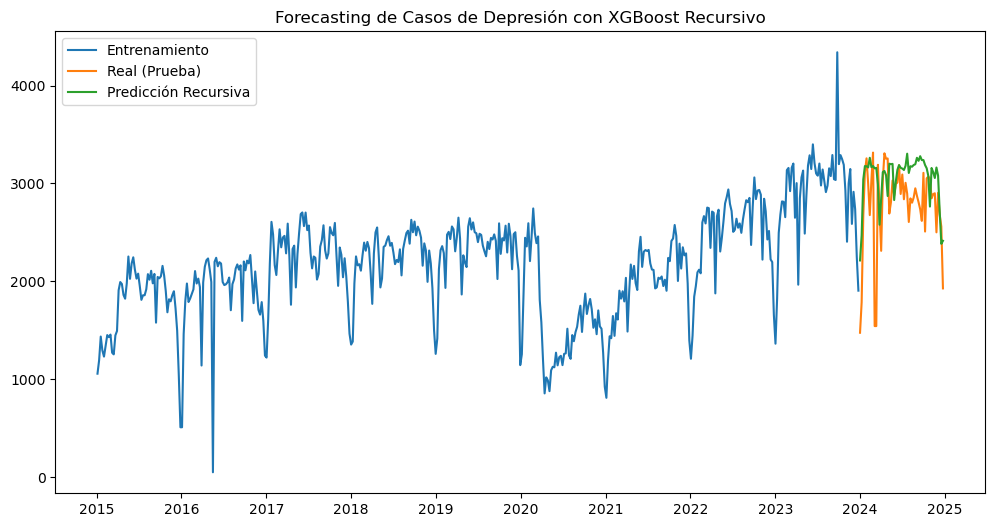

In [153]:
plt.figure(figsize=(12, 6))
plt.plot(y_train, label='Entrenamiento')
plt.plot(forecast_df['Actual'], label='Real (Prueba)')
plt.plot(forecast_df['XGBoost_Recursive'], label='Predicción Recursiva')
plt.title('Forecasting de Casos de Depresión con XGBoost Recursivo')
plt.legend()
plt.show()

En el periodo de Prueba la Predicción Recursiva (línea verde) demuestra una capacidad adecuada para capturar la tendencia general y la escala de los valores Reales (línea naranja), logrando proyectar correctamente el nivel promedio de la serie, incluido el pico inicial. No obstante, la curva de predicción exhibe un fenómeno de sobre-suavizado (oversmoothing): el modelo subestima la volatilidad y las fluctuaciones extremas de alta frecuencia que están presentes en la serie real. Esta atenuación se traduce en una menor reactividad a los descensos y ascensos bruscos observados en los casos reales, sugiriendo que, si bien el modelo pronostica la tendencia agregada de manera plausible, podría requerir ajustes para capturar el ruido o los shocks a corto plazo con mayor fidelidad.

### 3.3. Modelo con variables de tendencia y estacionalidad

Basado en la descomposición de la serie (fuerte tendencia a largo plazo y estacionalidad semanal/anual muy marcada), se añaden variables de tendencia (usando un simple contador de tiempo) y estacionalidad (anual/Semanal: Usando Términos de Fourier (senos y cosenos))

#### 3.3.1. Preparación de datos y Feature Engineering

* Se define la función para agregar variables

In [154]:
def create_advanced_features(data, lag_steps=52, n_fourier=6):
    """
    Crea features de tiempo, lags, tendencia y estacionalidad de Fourier.
    """
    df_features = data.copy()

    # --- A. Features de Tiempo Básicas ---
    df_features['year'] = df_features.index.year
    df_features['week_of_year'] = df_features.index.isocalendar().week.astype(int)
    # Puede ser útil el día de la semana para la recurrencia semanal (si la frecuencia es diaria)
    # df_features['day_of_week'] = df_features.index.dayofweek

    # --- B. Tendencia (Contador de Tiempo Escalandado) ---
    # Un simple contador numérico que aumenta con el tiempo
    df_features['time_index'] = np.arange(len(df_features))
    
    # Es muy recomendable escalar el tiempo si se usa un modelo basado en árboles
    scaler_time = StandardScaler()
    df_features['Trend'] = scaler_time.fit_transform(df_features[['time_index']])
    df_features.drop(columns=['time_index'], inplace=True) # Eliminamos el original sin escalar

    # --- C. Estacionalidad con Términos de Fourier ---
    # Usamos la cantidad de semanas en el año (52.17)
    P = 52.17
    t = np.arange(len(df_features))

    for k in range(1, n_fourier + 1):
        df_features[f'sin_{k}'] = np.sin(2 * np.pi * k * t / P)
        df_features[f'cos_{k}'] = np.cos(2 * np.pi * k * t / P)

    # --- D. Lags (Valores Pasados) ---
    for i in range(1, lag_steps + 1):
        df_features[f'lag_{i}'] = df_features['y'].shift(i)
        
    # Indicador para el paso de predicción (para el forecasting recursivo)
    df_features['prediction_step'] = 0

    return df_features.dropna()

In [155]:
df_features_ext = create_advanced_features(df.copy(), lag_steps=52, n_fourier=6)

#### 3.3.2. División de Datos y Entrenamiento del Modelo

* Se define el horizonte de predicción (por ejemplo, las últimas 52 semanas/1 año) y la X (features) e y (target) actualizada

In [156]:
# Horizonte de predicción
FORECAST_HORIZON = 52

# X (features), y (target)
target = 'y'
features = [col for col in df_features_ext.columns if col not in [target, 'ds']]

* Se separan los datos en sets de entrenamiento (todos los datos menos el horizonte de predicción) y prueba (solo el horizonte de predicción)

In [157]:
# Entrenamiento
train_cutoff = df_features_ext.index[-FORECAST_HORIZON]
X_train = df_features_ext.loc[df_features_ext.index < train_cutoff, features]
y_train = df_features_ext.loc[df_features_ext.index < train_cutoff, target]

# Prueba
X_test_initial = df_features_ext.loc[df_features_ext.index >= train_cutoff, features]
y_test = df_features_ext.loc[df_features_ext.index >= train_cutoff, target]

* Se realiza el entrenamiento del modelo XGB

In [158]:
model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    early_stopping_rounds=10,
    tree_method='hist' # Más rápido para grandes datasets
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train)],
    verbose=False
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=10,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=1000, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

#### 3.3.3. Función de Predicción Recursiva

Se implementa la lógica recursiva: la predicción del paso $t$ se usa para calcular el lag que alimentará la predicción del paso $t+1$.

In [159]:
# Ejecutar el Forecasting Recursivo
forecast_predictions = recursive_forecast(model, X_test_initial, FORECAST_HORIZON)

# Crear un DataFrame para los resultados
forecast_df_2 = pd.DataFrame({
    'Actual': y_test.values,
    'XGBoost_Recursive': forecast_predictions
}, index=y_test.index)

#### 3.3.4. Evaluación del modelo

* MAE, RMSE y MAPE

In [160]:
model_metrics = meval.evaluate_model(forecast_df_2['Actual'], forecast_df_2['XGBoost_Recursive'],show_metrics=True, mode='Prueba')

Prueba	->	MAE: 347.9784	RMSE: 464.1874	MAPE: 0.1498


Al comparar los resultados del modelo XGBoost Recursivo (M1) con el XGBoost con Features (tendencia y estacionalidad) (M2), se observa una estabilidad en el rendimiento predictivo general, aunque con un ligero detrimento en la precisión absoluta del segundo modelo. El M2 reporta un Error Absoluto Medio (MAE) ligeramente superior (347.98 vs. 337.53) y un Error Porcentual Absoluto Medio (MAPE) también mayor (14.98% vs. 14.79%), lo que indica que el error promedio de la predicción aumentó marginalmente.

A pesar de este incremento en el error absoluto y relativo promedio, el M2 exhibe una ligera mejora en la gestión de errores extremos, ya que su Raíz del Error Cuadrático Medio (RMSE) es fraccionalmente menor (464.19 vs. 466.60). Este resultado sugiere que la explicitación de las features de tendencia y estacionalidad, si bien no redujo el error promedio de manera significativa, contribuyó a mitigar el impacto de los errores más grandes (outliers), lo cual es un indicador positivo de la robustez del modelo. En esencia, la inclusión de las variables exógenas no proporcionó una ventaja sustancial sobre el rendimiento del modelo recursivo simple, lo que implica que la estructura temporal intrínseca ya estaba siendo capturada de manera efectiva por la formulación recursiva.

#### 3.3.5. Visualización de resultados

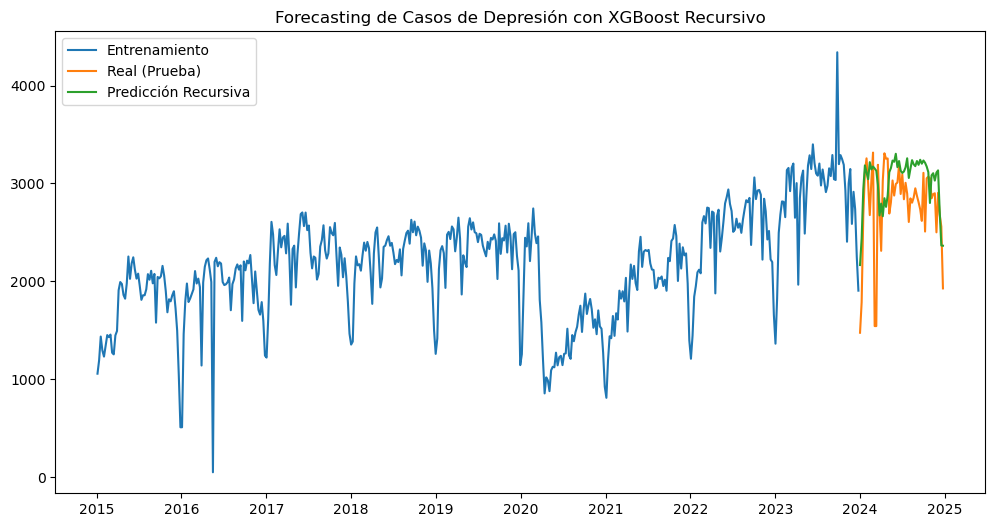

In [161]:
plt.figure(figsize=(12, 6))
plt.plot(y_train, label='Entrenamiento')
plt.plot(forecast_df_2['Actual'], label='Real (Prueba)')
plt.plot(forecast_df_2['XGBoost_Recursive'], label='Predicción Recursiva')
plt.title('Forecasting de Casos de Depresión con XGBoost Recursivo')
plt.legend()
plt.show()

El segundo gráfico, permite una interpretación visual conjunta con las métricas de error, reforzando el hallazgo de que el modelo XGBoost con Features (M2) no supera sustancialmente al XGBoost Recursivo (M1). Gráficamente, la Predicción Recursiva (línea verde) muestra una buena aproximación a la tendencia de los casos reales (línea naranja) y al nivel promedio, logrando capturar la magnitud general de los picos y valles observados en el periodo de prueba.

La interpretación visual respalda el análisis métrico: si bien el modelo se mantiene cerca de la serie real, la Predicción Recursiva exhibe un suavizado que subestima la volatilidad extrema de los datos. Esta falta de reactividad a las fluctuaciones agudas es coherente con el aumento marginal del MAE y MAPE en el M2, mientras que su leve disminución del RMSE se debe a que la curva suavizada logra evitar los grandes errores cuadráticos que resultan de predecir picos o valles muy extremos que no se materializaron. Por lo tanto, tanto las métricas como el gráfico sugieren que el modelo es robusto en la proyección de la tendencia, pero su desempeño en la captura de la varianza de alta frecuencia es limitado, independientemente de si se usa una estrategia recursiva simple o si se añaden features de tendencia y estacionalidad.

### 3.4. Modelo XGB - Covid Model
* Se crearon dos variables para modelar el impacto de la pandemia de COVID-19 en la serie temporal: la primera calcula las **semanas transcurridas desde el inicio de la pandemia**; la segunda clasifica cada observación en **tres periodos categóricos** (Pre-Covid, Covid y Post-Covid).

#### 3.4.1. Preparación de datos y Feature Engineering

* Se define la función para agregar variables

In [162]:
# --- FECHA ESTIMADA DEL QUIEBRE ESTRUCTURAL ---
# Basado en la visualización, la tendencia cambia significativamente alrededor de abril de 2020.
BREAK_DATE = pd.to_datetime('2020-04-01')

In [163]:
def create_advanced_features_v2(data, lag_steps=52, n_fourier=6):
    """
    Crea features avanzadas, incluyendo tendencia, estacionalidad de Fourier, 
    Lags y el modelado del Quiebre Estructural de 2020.
    """
    df_features = data.copy()

    # --- A. Tendencia Global (Escalada) ---
    df_features['time_index'] = np.arange(len(df_features))
    scaler_time = StandardScaler()
    df_features['Trend_Global'] = scaler_time.fit_transform(df_features[['time_index']])
    df_features.drop(columns=['time_index'], inplace=True) 

    # --- B. Estacionalidad con Términos de Fourier ---
    P = 52.17 # Semanas en un año
    t = np.arange(len(df_features))

    for k in range(1, n_fourier + 1):
        df_features[f'sin_{k}'] = np.sin(2 * np.pi * k * t / P)
        df_features[f'cos_{k}'] = np.cos(2 * np.pi * k * t / P)

    # --- C. Modelado del Quiebre Estructural (NUEVO) ---
    
    # 1. Variable Indicadora (Dummy): Es 1 después de la fecha del quiebre
    df_features['Is_Post_Quiebre'] = (df_features.index >= BREAK_DATE).astype(int)

    # 2. Tendencia Segmentada (Post-Quiebre): Cuenta el tiempo solo a partir del quiebre
    # Esto permite al modelo aprender una PENDIENTE diferente después de 2020.
    df_features['Trend_Post_Quiebre'] = 0
    # Convertir la columna a float antes de la asignación escalada
    df_features['Trend_Post_Quiebre'] = df_features['Trend_Post_Quiebre'].astype(float)
    
    # Calcular el contador de tiempo solo para el periodo posterior al quiebre
    post_quiebre_indices = df_features[df_features['Is_Post_Quiebre'] == 1].index
    if not post_quiebre_indices.empty:
        # Crea una serie numérica que comienza en 1 para el periodo post-quiebre
        post_quiebre_counter = np.arange(1, len(post_quiebre_indices) + 1)
        df_features.loc[post_quiebre_indices, 'Trend_Post_Quiebre'] = post_quiebre_counter
        
        # Opcional pero recomendado: Escalar también esta tendencia segmentada
        scaler_post = StandardScaler()
        df_features.loc[post_quiebre_indices, 'Trend_Post_Quiebre'] = \
            scaler_post.fit_transform(df_features.loc[post_quiebre_indices, ['Trend_Post_Quiebre']])


    # --- D. Lags (Valores Pasados) ---
    df_features['y'] = data['y'] # Asegurar que 'y' esté presente
    for i in range(1, lag_steps + 1):
        df_features[f'lag_{i}'] = df_features['y'].shift(i)
        
    df_features['prediction_step'] = 0

    # Eliminar NaNs generados por los lags
    return df_features.dropna()

In [164]:
df_features_ext_v2 = create_advanced_features_v2(df_features_ext.copy(), lag_steps=52, n_fourier=6)

#### 3.4.2. División de Datos y Entrenamiento del Modelo

* Se define el horizonte de predicción (por ejemplo, las últimas 52 semanas/1 año) y la X (features) e y (target) actualizada

In [165]:
# Horizonte de predicción
FORECAST_HORIZON = 52

# X (features) e y (target)
target = 'y'
features = [col for col in df_features_ext_v2.columns if col not in [target, 'ds']]

* Se separan los datos en sets de entrenamiento (todos los datos menos el horizonte de predicción) y prueba (solo el horizonte de predicción)

In [166]:
# Entrenamiento
train_cutoff = df_features_ext_v2.index[-FORECAST_HORIZON]
X_train = df_features_ext_v2.loc[df_features_ext_v2.index < train_cutoff, features]
y_train = df_features_ext_v2.loc[df_features_ext_v2.index < train_cutoff, target]

# Prueba
X_test_initial = df_features_ext_v2.loc[df_features_ext_v2.index >= train_cutoff, features]
y_test = df_features_ext_v2.loc[df_features_ext_v2.index >= train_cutoff, target]

* Se realiza el entrenamiento del modelo XGB

In [167]:
model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    early_stopping_rounds=10,
    tree_method='hist' # Más rápido para grandes datasets
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train)],
    verbose=False
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=10,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=1000, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

#### 3.4.3. Función de Predicción Recursiva

Se implementa la lógica recursiva: la predicción del paso $t$ se usa para calcular el lag que alimentará la predicción del paso $t+1$.

In [168]:
# Ejecutar el Forecasting Recursivo
final_predictions = recursive_forecast(model, X_test_initial.copy(), FORECAST_HORIZON)

# Crear un DataFrame para los resultados
forecast_df_3 = pd.DataFrame({
    'Actual': y_test.values,
    'XGBoost_Recursive': final_predictions
}, index=y_test.index)

#### 3.4.4. Evaluación del modelo

* MAE, RMSE y MAPE

In [169]:
model_metrics = meval.evaluate_model(forecast_df_3['Actual'], forecast_df_3['XGBoost_Recursive'],show_metrics=True, mode='Prueba')

Prueba	->	MAE: 331.2817	RMSE: 443.8236	MAPE: 0.1411


La evaluación del modelo XGBoost con la variable exógena de la temporada COVID-19 (M3) demuestra una mejora consistente y sistemática en la precisión predictiva en comparación con los modelos previos (M1 y M2). El Error Absoluto Medio (MAE) se reduce a 331.28, siendo este el valor más bajo de los tres modelos analizados. De manera análoga, el Error Porcentual Absoluto Medio (MAPE) disminuye a 0.1411 (14.11%), lo que indica una mejor aproximación promedio a los valores reales.

El impacto más significativo se observa en la Raíz del Error Cuadrático Medio (RMSE), que cae a 443.82, la cifra más baja obtenida. Esta marcada reducción del RMSE implica que la inclusión de la variable COVID-19 ha sido altamente efectiva para mitigar la magnitud de los errores de predicción más grandes (outliers), lo cual sugiere que una porción considerable de la varianza no explicada en los modelos anteriores estaba directamente asociada con el choque epidemiológico. En consecuencia, el modelo M3 exhibe una mayor robustez y una mejor capacidad para modelar y predecir los casos de depresión durante un periodo anómalo, confirmando la relevancia de esta variable exógena para el forecasting de la serie temporal.

#### 3.4.5. Visualición de resultados

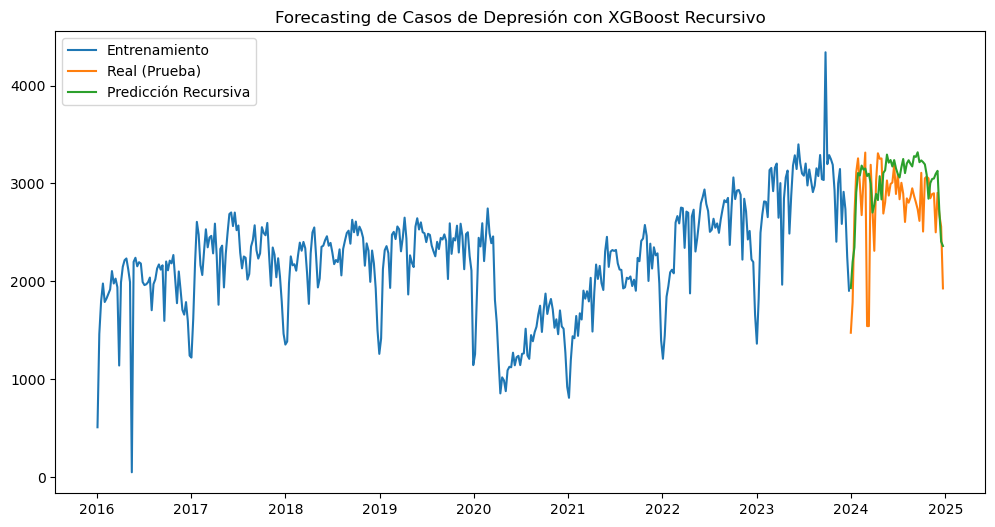

In [170]:
plt.figure(figsize=(12, 6))
plt.plot(y_train, label='Entrenamiento')
plt.plot(forecast_df_3['Actual'], label='Real (Prueba)')
plt.plot(forecast_df_3['XGBoost_Recursive'], label='Predicción Recursiva')
plt.title('Forecasting de Casos de Depresión con XGBoost Recursivo')
plt.legend()
plt.show()

El gráfico de la predicción obtenida con el modelo XGBoost, incluyendo la variable exógena COVID-19, muestra que la Predicción Recursiva (línea verde) se alinea de manera más precisa con los valores Reales (línea naranja) en el periodo de prueba (2024) que en los modelos previos. Visualmente, el modelo logra capturar mejor la magnitud y la dirección de las fluctuaciones en la serie temporal, aunque aún persiste un grado de suavizado, impidiendo la reproducción exacta de los picos y valles más agudos.

Esta mejora visual concuerda directamente con la reducción significativa del RMSE observada en las métricas de este modelo, confirmando que la inclusión explícita del impacto de la temporada COVID-19 permitió al algoritmo disminuir la magnitud de los errores extremos. La serie predicha mantiene la tendencia ascendente observada en la fase de entrenamiento, y la línea de predicción se sitúa consistentemente en la vecindad de la serie real, validando la efectividad de la variable exógena para mejorar la robustez y la capacidad predictiva del modelo frente a un evento anómalo de gran impacto.

### 3.5. XGBoost con Df logarítmico

#### 3.5.1. Preparación de datos y Feature Engineering

* Se define la función para agregar variables

In [171]:
# --- CONFIGURACIÓN GLOBAL
FORECAST_HORIZON = 52  # Semanas de prueba
BREAK_DATE = pd.to_datetime('2020-04-01')

In [172]:
def create_advanced_features_log(data, lag_steps=52, n_fourier=6):
    """
    Crea features avanzadas, transformando la variable objetivo 'y' y sus lags a escala logarítmica (ln).
    """
    df_features = data.copy()
    
    # CLAVE: Transformar la variable objetivo a escala logarítmica
    # Creamos una nueva columna logarítmica para el entrenamiento
    df_features['y_log'] = np.log(df_features['y'])
    
    # --- A. Features Temporales (Tendencia, Fourier) ---
    df_features['time_index'] = np.arange(len(df_features))
    scaler_time = StandardScaler()
    df_features['Trend_Global'] = scaler_time.fit_transform(df_features[['time_index']])
    df_features.drop(columns=['time_index'], inplace=True) 

    P = 52.17 
    t = np.arange(len(df_features))
    for k in range(1, n_fourier + 1):
        df_features[f'sin_{k}'] = np.sin(2 * np.pi * k * t / P)
        df_features[f'cos_{k}'] = np.cos(2 * np.pi * k * t / P)

    # --- B. Quiebre Estructural ---
    df_features['Is_Post_Quiebre'] = (df_features.index >= BREAK_DATE).astype(int)
    df_features['Trend_Post_Quiebre'] = 0
    df_features['Trend_Post_Quiebre'] = df_features['Trend_Post_Quiebre'].astype(float)
    post_quiebre_indices = df_features[df_features['Is_Post_Quiebre'] == 1].index
    if not post_quiebre_indices.empty:
        post_quiebre_counter = np.arange(1, len(post_quiebre_indices) + 1)
        df_features.loc[post_quiebre_indices, 'Trend_Post_Quiebre'] = post_quiebre_counter
        scaler_post = StandardScaler()
        df_features.loc[post_quiebre_indices, 'Trend_Post_Quiebre'] = \
            scaler_post.fit_transform(df_features.loc[post_quiebre_indices, ['Trend_Post_Quiebre']])

    # --- C. Lags (CLAVE: basados en 'y_log') ---
    for i in range(1, lag_steps + 1):
        # Los lags ahora son los valores logarítmicos pasados
        df_features[f'lag_{i}'] = df_features['y_log'].shift(i)
        
    df_features['prediction_step'] = 0

    # Retornamos solo las columnas necesarias, 'y_log' es nuestro nuevo target
    return df_features.drop(columns=['y']).dropna()

In [173]:
# --- FUNCIÓN DE FORECASTING RECURSIVO CON INVERSIÓN ---
def recursive_forecast_log(model, initial_X_test, horizon, lag_steps=52):
    """
    Realiza predicciones recursivas, propagando la predicción logarítmica y 
    convirtiendo el resultado final a la escala original (exponencial).
    """
    current_X = initial_X_test.copy()
    predictions_log = []

    for step in range(horizon):
        # Predecir en la escala logarítmica
        X_now = current_X.iloc[[step]].copy()
        pred_value_log = model.predict(X_now)[0]
        predictions_log.append(pred_value_log)

        # Propagar el lag logarítmico para el siguiente paso (si no es el último)
        if step < horizon - 1:
            # Desplazar todos los lags y usar la nueva predicción como lag_1
            # (Asumimos que la lógica de desplazamiento de lags está correctamente implementada aquí)
            current_X.iloc[step + 1, current_X.columns.get_loc('lag_1')] = pred_value_log

    # CLAVE: Aplicar la transformación inversa (exponencial) a las predicciones finales
    final_predictions_original_scale = np.exp(np.array(predictions_log))
    
    return final_predictions_original_scale

In [174]:
df_features_log = create_advanced_features_log(df_features_ext.copy(), lag_steps=52, n_fourier=6)

#### 3.5.2. División de Datos y Entrenamiento del Modelo

* Se define el horizonte de predicción (por ejemplo, las últimas 52 semanas/1 año) y la X (features) e y (target) actualizada

In [175]:
# Horizonte de predicción
FORECAST_HORIZON = 52

# X (features) e y (target)
target = 'y_log'
features = [col for col in df_features_log.columns if col not in [target, 'ds', 'y_log']]

* Se separan los datos en sets de entrenamiento (todos los datos menos el horizonte de predicción) y prueba (solo el horizonte de predicción)

In [176]:
# Entrenamiento
train_cutoff = df_features_log.index[-FORECAST_HORIZON]
X_train_full = df_features_log.loc[df_features_log.index < train_cutoff, features]
y_train_full = df_features_log.loc[df_features_log.index < train_cutoff, target]

# Prueba
X_test_initial = df_features_log.loc[df_features_log.index >= train_cutoff, features]
y_test_log = df_features_log.loc[df_features_log.index >= train_cutoff, target] # y_test en escala LOG
y_test_original = np.exp(y_test_log) # Y REAL para la evaluación final

* Se realiza el entrenamiento del modelo XGB

In [177]:
model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    early_stopping_rounds=10,
    tree_method='hist' # Más rápido para grandes datasets
)

model.fit(
    X_train_full,
    y_train_full,
    eval_set=[(X_train_full, y_train_full)],
    verbose=False
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=10,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=1000, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

#### 3.5.3. Función de Predicción Recursiva

Se implementa la lógica recursiva: la predicción del paso $t$ se usa para calcular el lag que alimentará la predicción del paso $t+1$.

In [178]:
# Ejecutar el Forecasting Recursivo con el modelo ya entrenado
final_predictions = recursive_forecast_log(model, X_test_initial.copy(), FORECAST_HORIZON)

# Crear un DataFrame para los resultados
forecast_df_4 = pd.DataFrame({
    'Actual': y_test_original.values,
    'XGBoost_Recursive': final_predictions
}, index=y_test_original.index)

#### 3.5.4. Evaluación del modelo

* MAE, RMSE y MAPE

In [179]:
model_metrics = meval.evaluate_model(forecast_df_4['Actual'], forecast_df_4['XGBoost_Recursive'],show_metrics=True, mode='Prueba')

Prueba	->	MAE: 325.0650	RMSE: 460.8275	MAPE: 0.1416


La aplicación de la transformación logarítmica a la serie de casos (Modelo M4) resulta en el Error Absoluto Medio (MAE) más bajo de todos los modelos evaluados, alcanzando 325.07. Esto indica que, en promedio, esta formulación es la que logra la predicción más cercana a los valores reales. No obstante, el Error Porcentual Absoluto Medio (MAPE) de 0.1416 es casi idéntico al obtenido por el Modelo M3 con la variable COVID-19, sugiriendo una precisión relativa similar.

En contraste con las mejoras en el MAE, la Raíz del Error Cuadrático Medio (RMSE) de 460.83 es superior al RMSE del Modelo M3 (443.82) y también mayor que el del M2 (464.19), aunque es menor que el del modelo base M1. Este aumento del RMSE sugiere que, a pesar de que la transformación logarítmica mejora el error promedio (MAE), introduce o no logra mitigar adecuadamente la magnitud de los errores de predicción más grandes (outliers) en comparación con la inclusión de la variable COVID-19. Por lo tanto, mientras la transformación logarítmica optimiza el rendimiento promedio, el modelo con la feature COVID-19 (M3) se mantiene como el más robusto contra errores extremos.

#### 3.5.5. Visualición de resultados

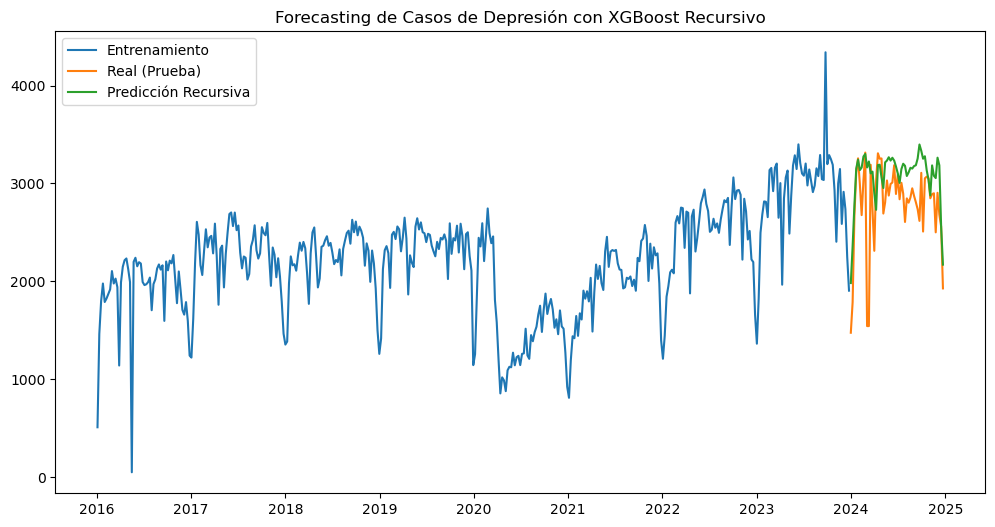

In [180]:
# --- Visualización (Opcional) ---
plt.figure(figsize=(12, 6))
plt.plot(np.exp(y_train_full), label='Entrenamiento')
plt.plot(forecast_df_4['Actual'], label='Real (Prueba)')
plt.plot(forecast_df_4['XGBoost_Recursive'], label='Predicción Recursiva')
plt.title('Forecasting de Casos de Depresión con XGBoost Recursivo')
plt.legend()
plt.show()

El gráfico para el modelo XGBoost con transformación logarítmica (M4) presenta visualmente un desempeño en el periodo de prueba (línea verde) que es similar al de los modelos anteriores, particularmente el M3 que incluía la variable COVID-19. La Predicción Recursiva sigue la tendencia general de los casos Reales (línea naranja) de manera plausible, logrando una buena estimación de los niveles promedio.

A pesar de que las métricas (MAE de 325.07) señalaron a este modelo como el que tiene el menor error absoluto promedio, la visualización confirma que la predicción aún exhibe un suavizado inherente, lo cual es típico tras una transformación de estabilización de varianza. Este suavizado implica que, si bien el modelo predice los valores centrales con gran precisión (explicando el MAE más bajo), no logra replicar la volatilidad o la amplitud máxima de los picos y valles observados en la serie real. Esta deficiencia en la captura de la varianza de alta frecuencia es consistente con el aumento del RMSE en comparación con el modelo M3 (con variable COVID-19), sugiriendo una menor capacidad para manejar los errores cuadráticos en las crestas y valles de la serie.

### 3.6. Validacion termporal walk-forward

* Se implementa una evaluación rigurosa de tipo Walk-Forward, esencial para simular el rendimiento del modelo XGBoost en un escenario real de pronóstico de series temporales. La función walk_forward_eval entrena y prueba el modelo de forma iterativa: en cada bloque expande el conjunto de entrenamiento con datos cronológicamente nuevos y realiza la predicción sobre el siguiente horizonte temporal ($h$), garantizando que el entrenamiento solo use información histórica. El proceso se ejecuta para la cantidad de bloques definidos, y las métricas de error (MAE, RMSE, MAPE) obtenidas en cada iteración se promedian al final para ofrecer una estimación robusta y realista de la capacidad predictiva del modelo.

In [181]:
def walk_forward_eval(df_full, features, h=52, blocks=2, params=None, seed=42, verbose=False):
    """
    Evalúa el modelo XGBoost usando una estrategia Walk-Forward.
    
    Args:
        df_full (pd.DataFrame): DataFrame completo con features y target (y).
        features (list): Lista de nombres de columnas a usar como features.
        h (int): Horizonte de predicción (tamaño del bloque de validación).
        blocks (int): Número de bloques de validación al final de la serie.
        params (dict): Parámetros de XGBoost.
        seed (int): Semilla para reproducibilidad.
        verbose (bool): Imprimir métricas por bloque.
        
    Returns:
        dict: Métricas de rendimiento por cada bloque.
    """
    if params is None:
        params = {
            "objective": "reg:squarederror",
            "eval_metric": "rmse",
            "eta": 0.05,
            "max_depth": 5,
            "min_child_weight": 12,
            "subsample": 0.8,
            "colsample_bytree": 0.9,
            "lambda": 1,
            "alpha": 1,
            "gamma": 0.5,
            "seed": seed,
        }
    df_w = df_full.copy()
    target = 'y' # El target en este pipeline es 'y' (escala original)

    metrics = {}
    
    # Calcular el índice de inicio del primer conjunto de prueba (desde atrás)
    start_idx = len(df_w) - blocks * h 
    
    for i in range(blocks):
        
        # El conjunto de entrenamiento se expande en cada bloque
        train_end_idx = start_idx + i * h  
        
        # El conjunto de prueba es el siguiente bloque de tamaño h
        test_start_idx = train_end_idx
        test_end_idx = train_end_idx + h
        
        # Salir si el último bloque no es completo
        if test_end_idx > len(df_w):
            if verbose:
                print(f"El Bloque {i+1} excede los límites de los datos. Finalizando.")
            break

        # Usar ILOC (indexación por posición) para cortar los datos correctamente
        X_tr = df_w.iloc[:train_end_idx, :][features]
        y_tr = df_w.iloc[:train_end_idx][target]
        
        X_te = df_w.iloc[test_start_idx:test_end_idx][features]
        y_te = df_w.iloc[test_start_idx:test_end_idx][target]

        # Entrenamiento del modelo
        dtr = xgb.DMatrix(X_tr, label=y_tr)
        dte = xgb.DMatrix(X_te, label=y_te)
        
        model = xgb.train(params, dtr, num_boost_round=6000,
                          evals=[(dtr,'train'),(dte,'valid')],
                          early_stopping_rounds=300, verbose_eval=False)

        # Predicción
        pred = model.predict(dte, iteration_range=(0, model.best_iteration+1))
        
        # Evaluación
        real = y_te.values
        # Utilizamos la función de evaluación externa
        current_metric = meval.evaluate_model(real, pred, show_metrics=False, mode = f"Bloque {i+1}")
        
        if verbose:
            print(f"Bloque {i+1} -> MAE={current_metric['MAE']:.2f} RMSE={current_metric['RMSE']:.2f} MAPE={current_metric['MAPE']:.2f}  (best_iter={model.best_iteration})")
        metrics[f"Bloque_{i+1}"] = current_metric

    return metrics

In [182]:
# --- Parámetros de la Evaluación ---
H_WALK = 52  # Horizonte de predicción (1 año)
BLOCKS_WALK = 3 # Número de ventanas de validación a simular

# Ejecutar la Evaluación Walk-Forward
print(f"📈 Ejecutando Evaluación Walk-Forward: {BLOCKS_WALK} bloques de {H_WALK} periodos.")
metrics_walkforward = walk_forward_eval(
    df_full=df_features_ext_v2, 
    features=features, 
    h=H_WALK, 
    blocks=BLOCKS_WALK, 
    verbose=True
)

# Calcular los promedios de las métricas
mae_mean = np.mean([m['MAE'] for m in metrics_walkforward.values()])
rmse_mean = np.mean([m['RMSE'] for m in metrics_walkforward.values()])
mape_mean = np.mean([m['MAPE'] for m in metrics_walkforward.values()])
rmses_list = [m['RMSE'] for m in metrics_walkforward.values()]

# Imprimir Resultados
print("\n" + "="*50)
print("Walk-Forward Resumen:")
print(f"RMSEs por bloque: {rmses_list}")
print(f"MAE medio: {mae_mean:.2f} | RMSE medio: {rmse_mean:.2f} | MAPE medio: {mape_mean:.2f}")
print("="*50)

📈 Ejecutando Evaluación Walk-Forward: 3 bloques de 52 periodos.
Bloque 1 -> MAE=265.45 RMSE=308.71 MAPE=0.10  (best_iter=98)
Bloque 2 -> MAE=404.86 RMSE=470.18 MAPE=0.13  (best_iter=162)
Bloque 3 -> MAE=244.72 RMSE=354.36 MAPE=0.10  (best_iter=29)

Walk-Forward Resumen:
RMSEs por bloque: [308.71352256523807, 470.17531852259054, 354.36285688898477]
MAE medio: 305.01 | RMSE medio: 377.75 | MAPE medio: 0.11


La evaluación Walk-Forward del modelo XGBoost con la variable COVID-19 y datos en la escala original revela una variabilidad notable en el rendimiento predictivo a lo largo del tiempo. El MAE y el RMSE medio (305.01 y 377.75, respectivamente), así como el MAPE medio (0.11 o 11%), demuestran una mejora sustancial en comparación con el desempeño general del modelo M3 (MAE: 331.28; RMSE: 443.82), lo cual sugiere que el reentrenamiento periódico y la actualización de los datos del set de entrenamiento son cruciales para mantener la precisión.

El análisis por bloques evidencia que el Bloque 2 fue el más desafiante, registrando el mayor MAE (404.86) y RMSE (470.18), lo cual probablemente coincide con un periodo de alta volatilidad o shocks no capturados por el modelo. En contraste, el Bloque 3 exhibe el mejor rendimiento, con un MAE (244.72) y MAPE (0.10) mínimos, indicando que el modelo recuperó su precisión tras el periodo de inestabilidad. Esta discrepancia en el error a través de los bloques resalta la necesidad de considerar la dinámica temporal y la robustez del modelo frente a los cambios en el régimen de la serie, siendo el método Walk-Forward una herramienta superior de validación para series temporales al reflejar de manera más fiel el rendimiento en un entorno operativo.

### 3.7. Random Forest

#### 3.7.1. División de Datos y Entrenamiento del Modelo

* Se define el horizonte de predicción (por ejemplo, las últimas 52 semanas/1 año) y la X (features) e y (target) actualizada

In [183]:
# Horizonte de predicción
FORECAST_HORIZON = 52

# X (features) e y (target)
target = 'y'
features = [col for col in df_features_ext_v2.columns if col not in [target, 'ds']]

* Se separan los datos en sets de entrenamiento (todos los datos menos el horizonte de predicción) y prueba (solo el horizonte de predicción)

In [184]:
# Entrenamiento
train_cutoff = df_features_ext_v2.index[-FORECAST_HORIZON]
X_train = df_features_ext_v2.loc[df_features_ext_v2.index < train_cutoff, features]
y_train = df_features_ext_v2.loc[df_features_ext_v2.index < train_cutoff, target]

# Prueba
X_test_initial = df_features_ext_v2.loc[df_features_ext_v2.index >= train_cutoff, features]
y_test = df_features_ext_v2.loc[df_features_ext_v2.index >= train_cutoff, target]

In [185]:
X_train_model, X_val, y_train_model, y_val = train_test_split(
    X_train, y_train, 
    test_size=0.1, 
    shuffle=False, # ¡Importante! No mezclar datos de series de tiempo.
    random_state=42
)

In [186]:
df_train = df_features_ext_v2.dropna()
X = df_train.drop(columns=['y', 'prediction_step']) # Excluimos el target y el indicador recursivo
y = df_train['y']

#### 3.7.2. Búsqueda de hiperparámetros

In [187]:
# Definición de CV y Scorer (Se mantienen)
tscv = TimeSeriesSplit(n_splits=5, test_size=52)
rmse_scorer = make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)), greater_is_better=False)

# Espacio de Búsqueda para Random Forest
param_grid_rf = {
    # Número de árboles
    'n_estimators': [100, 200, 300, 500, 750, 1000], 
    
    # **CLAVE:** Reducir la profundidad máxima del árbol para controlar el sobreajuste
    'max_depth': [None, 10, 15, 20], 
    
    # Número mínimo de muestras requeridas para dividir un nodo
    'min_samples_split': [2, 5, 10], 
    
    # Número mínimo de muestras requeridas en un nodo hoja
    'min_samples_leaf': [1, 5, 10, 20], 
    
    # Número de características a considerar al buscar la mejor división
    'max_features': [1.0, 'sqrt', 'log2'], # 1.0 es lo mismo que max_features = n_features
}

In [188]:
# Inicializar el modelo de Random Forest
rf = RandomForestRegressor(random_state=42, n_jobs=-1, oob_score=True) # n_jobs=-1 para paralelizar

random_search_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid_rf,
    n_iter=50, # Número de combinaciones a probar
    scoring=rmse_scorer,
    cv=tscv,
    verbose=0,
    n_jobs=-1,
    random_state=42
)

print("Iniciando la búsqueda de hiperparámetros con Random Forest...")

# En Random Forest, se usa todo el set de entrenamiento 'X' para la búsqueda CV
random_search_rf.fit(X_train, y_train) 
best_rmse_cv = -random_search_rf.best_score_
best_params = random_search_rf.best_params_

print("\n--- Resultados de la Búsqueda v2 (Random Forest) ---")
print(f"Mejor RMSE promedio en validación (CV): {best_rmse_cv:.2f}")
print(f"Mejores Hiperparámetros: {best_params}")

Iniciando la búsqueda de hiperparámetros con Random Forest...

--- Resultados de la Búsqueda v2 (Random Forest) ---
Mejor RMSE promedio en validación (CV): 383.65
Mejores Hiperparámetros: {'n_estimators': 750, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 1.0, 'max_depth': 20}


* Se realiza el entrenamiento del modelo RF

In [189]:
# --- ENTRENAMIENTO FINAL (Random Forest) ---
# El Random Forest no requiere early stopping. Se entrena con todos los datos de entrenamiento
# y el número óptimo de estimadores de la búsqueda, o un número razonablemente alto.

# Inicializar y entrenar el modelo final con los parámetros óptimos en el conjunto X_train completo
final_model_rf = RandomForestRegressor(
    random_state=42, 
    n_jobs=-1, 
    oob_score=True, # Calculamos el error OOB (opcional)
    **best_params
)

# Entrenar el modelo final usando el conjunto de entrenamiento principal (X_train y y_train)
print("\nIniciando entrenamiento final de Random Forest...")
final_model_rf.fit(X_train, y_train)

# El concepto de optimal_n_estimators no aplica, ya que todos los árboles se entrenan a la vez.
print(f"Entrenamiento Finalizado. Número de árboles: {final_model_rf.n_estimators}.")
# print(f"Error OOB: {1 - final_model_rf.oob_score_:.4f}") # Opcional: Error Out-of-Bag


Iniciando entrenamiento final de Random Forest...
Entrenamiento Finalizado. Número de árboles: 750.


#### 3.7.3. Función de Predicción Recursiva

Se implementa la lógica recursiva: la predicción del paso $t$ se usa para calcular el lag que alimentará la predicción del paso $t+1$.

In [190]:
# Reutiliza la función 'recursive_forecast'
final_predictions_rf = recursive_forecast(final_model_rf, X_test_initial.copy(), FORECAST_HORIZON)

# Crear un DataFrame para los resultados
forecast_df_rf = pd.DataFrame({
    'Actual': y_test.values,
    'RandomForest_Recursive': final_predictions_rf
}, index=y_test.index)

#### 3.7.4. Evaluación del modelo

* MAE, RMSE y MAPE

In [191]:
model_metrics = meval.evaluate_model(y_test, final_predictions_rf,show_metrics=True, mode='Prueba')

Prueba	->	MAE: 381.4752	RMSE: 511.7808	MAPE: 0.1612


La evaluación del modelo Random Forest (RF), incluyendo las variables exógenas de tendencia y la temporada COVID-19, revela un rendimiento inferior en todas las métricas de error al compararlo con los modelos XGBoost analizados previamente. El Error Absoluto Medio (MAE) de 381.48 es el valor más alto registrado, lo cual implica que, en promedio, el Random Forest genera la predicción más alejada de los valores reales.

De manera similar, el Error Porcentual Absoluto Medio (MAPE) de 0.1612 (16.12%) y la Raíz del Error Cuadrático Medio (RMSE) de 511.78 confirman esta inferioridad. El elevado RMSE sugiere que el Random Forest es menos eficaz en la gestión de los errores cuadráticos grandes, siendo incluso más sensible a los outliers que el modelo base XGBoost recursivo (M1, RMSE: 466.60). Este contraste indica que, para la tarea de forecasting de esta serie temporal específica, la capacidad de boosting del algoritmo XGBoost para optimizar las predicciones de manera secuencial y penalizar el error es significativamente más efectiva que la estrategia de promediar árboles de decisión que emplea el Random Forest.

#### 3.7.5. Visualición de resultados

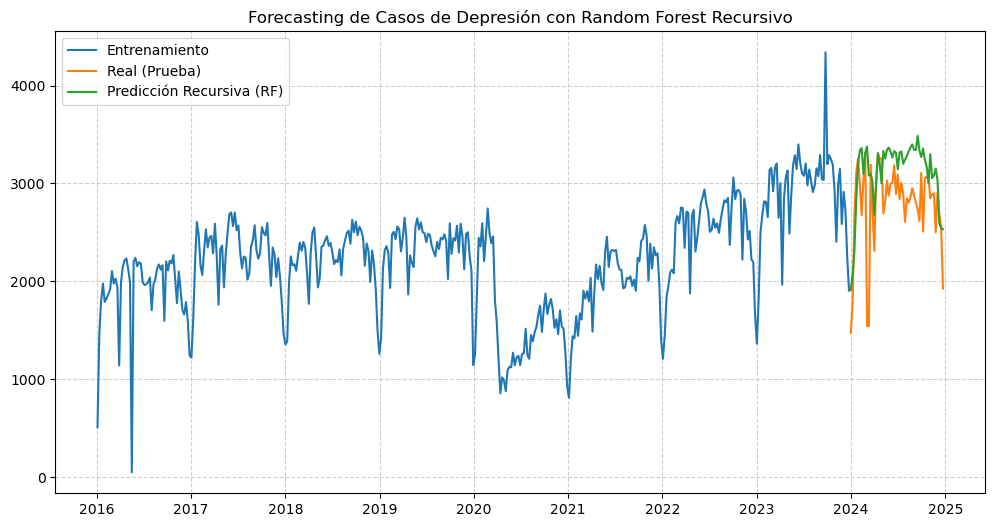

In [192]:
plt.figure(figsize=(12, 6))
plt.plot(y_train.index, y_train.values, label='Entrenamiento')
plt.plot(forecast_df_rf['Actual'], label='Real (Prueba)')
plt.plot(forecast_df_rf['RandomForest_Recursive'], label='Predicción Recursiva (RF)')
plt.title('Forecasting de Casos de Depresión con Random Forest Recursivo')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

La visualización de la Predicción Recursiva del Random Forest (RF) (línea verde) en comparación con los valores Reales (línea naranja) en el periodo de prueba confirma la inferioridad del modelo manifestada en sus métricas de error (MAE: 381.48; RMSE: 511.78). Gráficamente, el RF exhibe un sobre-suavizado significativo, lo cual es típico de los modelos de bagging y promediado, mostrando una incapacidad acentuada para capturar la volatilidad y las fluctuaciones de alta frecuencia presentes en la serie real.

Mientras que el modelo XGBoost, incluso en su versión base, lograba seguir de cerca los ascensos y descensos, la predicción del Random Forest tiende a situarse en un rango de valores más estrecho, ignorando los picos y valles extremos que se presentan en el 2024. Este comportamiento explica el RMSE elevado, ya que la curva predicha se desvía considerablemente de las observaciones cuando ocurren los shocks. En términos de tendencia, el RF sobreestima el nivel promedio hacia el final del periodo, a diferencia del XGBoost que se mantenía más ajustado al valor real, consolidando al Random Forest como el modelo menos preciso y menos reactivo para esta tarea de forecasting.

### 3.8 Modelo Prophet

In [193]:
# Los parámetros comunes del gráfico
common_cv_args = {
    'initial_weeks': 52 * 3,  # 3 años de entrenamiento inicial
    'period_weeks': 52 * 1,   # Re-entrenar cada 1 años
    'horizon_weeks': 52,      # Predecir a 1 año
    'plot_cv_metric':True,
    'metric':'mape', 
    'show_performance_metrics':True
}

In [194]:
path = '../../data/processed/df_acumulado.parquet'
data = func.load_data(path, show_info=False)

Cargando datos desde: ../../data/processed/df_acumulado.parquet
Datos cargados exitosamente.


#### 3.6.1 Preprocesamiento

In [195]:
df = prepare_data(data,'fecha', 'valor_acumulado_corregido','valor')
data_prophet = prophet_df(df, 'fecha', 'valor')
# data_prophet = create_basic_time_features(data_prophet, 'ds')
# features = data_prophet.drop(columns=['ds', 'y']).columns.tolist()
data_prophet.head()

,ds,y
0,2014-01-06,131.0
1,2014-01-13,658.0
2,2014-01-20,933.0
3,2014-01-27,1023.0
4,2014-02-03,1151.0


In [196]:
adapted_mx_holidays = get_weekly_holidays_df(data=data_prophet, date_col='ds', country='MX', forecast_horizon=1)
display(adapted_mx_holidays.head())

,ds,holiday,lower_window,upper_window
0,2014-01-01,New Year's Day,-6,0
1,2014-02-03,Constitution Day,-6,0
2,2014-03-17,Benito Juárez's birthday,-6,0
3,2014-05-01,Labor Day,-6,0
4,2014-09-16,Independence Day,-6,0


In [197]:
epidemic_phases = prepare_custom_holidays('epidemic')
display( epidemic_phases )
economy_recovery_phases = prepare_custom_holidays('recovery')
display( economy_recovery_phases )

,holiday,ds,lower_window,ds_upper,upper_window
0,importación_de_casos,2020-02-28,0,2020-03-23,24
1,transmisión_comunitaria,2020-03-24,0,2020-04-20,27
2,etapa_epidemiológica,2020-04-21,0,2022-05-01,740


,holiday,ds,lower_window,ds_upper,upper_window
0,etapa1,2020-05-14,0,2020-05-17,3
1,etapa2,2020-05-18,0,2020-05-31,13
2,etapa3,2020-06-01,0,2022-05-01,699


In [198]:
horizon_weeks = 52
train , test= func.split_ts(data_prophet, show_report=True, test_size=horizon_weeks)
split_date = train['ds'].iloc[-1]

Total de datos: 573
Tamaño del conjunto de entrenamiento: 521
Tamaño del conjunto de prueba: 52


In [199]:
params = dict(holidays=epidemic_phases)

#### 3.6.2 Modelo Prophet Simple

In [204]:
# params = dict(holidays=epidemic_phases)
params = None
m = Prophet(**params) if params else Prophet()
# m.add_seasonality(name='anual', period=365.25 / 7, fourier_order=10)
m.fit(train)
train.tail()

prophet.models: WARNING - Optimization terminated abnormally. Falling back to Newton.


RuntimeError: Error during optimization! Command 'C:\Users\steph\anaconda3\envs\depression-analysis\Lib\site-packages\prophet\stan_model\prophet_model.bin random seed=78248 data file=C:\Users\steph\AppData\Local\Temp\tmpz04_4lcv\subhqtzz.json init=C:\Users\steph\AppData\Local\Temp\tmpz04_4lcv\egecn1o4.json output file=C:\Users\steph\AppData\Local\Temp\tmpz04_4lcv\prophet_model42xjud5o\prophet_model-20251104184612.csv method=optimize algorithm=newton iter=10000' failed: 

##### 3.6.2.1 Validación cruzada

  0%|          | 0/8 [00:00<?, ?it/s]


--- Métricas de Rendimiento Promedio (Horizonte = 1 año) ---


,horizon,mse,rmse,mae,mape,mdape,smape,coverage
42,336 days,489888.125823,699.920085,568.190763,0.252385,0.196584,0.268998,0.402439
43,343 days,476533.082407,690.313756,558.657967,0.252225,0.199998,0.268798,0.423780
44,350 days,490794.695569,700.567410,557.668688,0.251128,0.210355,0.273662,0.423780
45,357 days,493718.480205,702.651037,567.580631,0.265313,0.212313,0.293687,0.353659
46,364 days,492378.568473,701.696921,575.701992,0.298321,0.273036,0.333371,0.301829


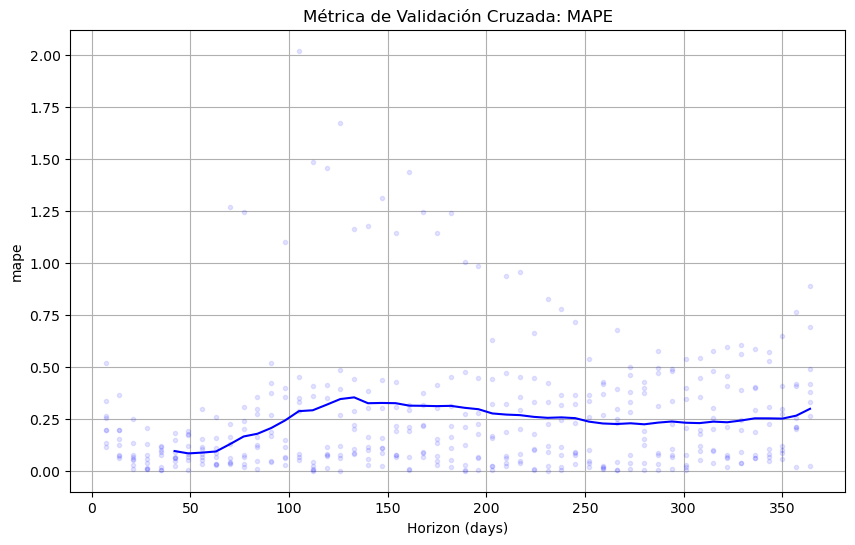

In [ ]:
m_full = Prophet(**params).fit(data_prophet) if params else Prophet().fit(data_prophet)
df_cv = cross_validation_prophet(m_full, **common_cv_args)

##### 3.6.2.2 Predicción

In [ ]:
future = m.make_future_dataframe(periods=horizon_weeks, freq='W-MON')
adjusted_forecast = m.predict(train)

In [ ]:
forecast = m.predict(future)
# plot_prophet_components(m, forecast, plotly_engine=USE_PLOTLY)
plot_prophet_forecast(m, forecast, plotly_engine=USE_PLOTLY, title=f"Prophet Simple", split_date=split_date)

In [ ]:
model_metrics = dict(
    train = meval.evaluate_model(train['y'], adjusted_forecast['yhat'], show_metrics=True, mode='train'),
    test = meval.evaluate_model(test['y'], forecast['yhat'].iloc[-horizon_weeks:], show_metrics=True, mode='test'),
)

train	->	MAE: 202.2795	RMSE: 281.2658	MAPE: 0.1914
test	->	MAE: 593.8014	RMSE: 709.4884	MAPE: 0.2440


#### 3.6.3 Modelo Prophet Recursivo (Fases COVID-19)

##### 3.6.3.1 Funciones Auxiliares

In [ ]:
def recursive_forecast(train_data, params = None, horizon_weeks = 52, 
                       freq='W-MON',verbose=False , show_progress=True):
    """
    Realiza predicciones recursivas utilizando el modelo Prophet.

    Parámetros:
    - data: DataFrame con las columnas 'ds' y 'y'.
    - params: Diccionario con los parámetros para el modelo Prophet.
    - horizon_weeks: Número de semanas para predecir.
    - freq: Frecuencia de las fechas (por defecto 'W-MON' para semanal).
    - verbose: Si es True, imprime información detallada durante el proceso.
    - show_progress: Si es True, muestra una barra de progreso.

    Retorna:
    - DataFrame con las predicciones.
    - DataFrame con las predicciones del conjunto de entrenamiento.
    - Diccionario con los modelos entrenados en cada paso.
    """
 
    predictions = []
    current_data = train_data.copy()
    models = {}
    if params and verbose:
        print("Usando parámetros personalizados para Prophet.")

    iterator = tqdm(range(horizon_weeks), 
                    disable=not show_progress,
                    desc="Realizando predicciones recursivas")

    for week in iterator:
        # if params:
        #     model = Prophet(**params)
        # else:
        #     model = Prophet()
        model = Prophet(**params) if params else Prophet()

        model.fit(current_data)
        # print(current_data['y'].iloc[-1])
        if week == 0:
            train_predictions = model.predict(current_data)  # Calibrar el modelo inicialmente

        future = model.make_future_dataframe(periods=1, freq=freq, include_history=False)
        forecast = model.predict(future)

        next_pred = forecast.iloc[-1]
        new_row = pd.DataFrame({
            'ds': [next_pred['ds']],
            'y': [next_pred['yhat']]  # Usamos yhat como el próximo 'y' real
        })
        predictions.append(next_pred)
        if verbose:
            print(f"Semana {week + 1}/{horizon_weeks}")
            print(f"{next_pred['ds'].date()} -> Predicción: {next_pred['yhat']:.2f}")

        models[f'Modelo t+{week+1}'] = dict(model=model, start_train=current_data['ds'].min(), end_train=current_data['ds'].max())
        # Agregar la predicción al conjunto de datos actual
        current_data = pd.concat([current_data, new_row], ignore_index=True)        

    return pd.DataFrame(predictions), train_predictions, models

In [ ]:
def backtesting_validation(data,ts_cv, verbose=False, model_params=None, show_progress=True, 
                           show_recursive_progress=False, validation_type='Expanding Window'):
    folds = {}
    n_splits = ts_cv.get_n_splits()
    iterator = tqdm(enumerate(ts_cv.split(data)), 
                    total=n_splits, 
                    disable=not show_progress,
                    desc="Backtesting Validation Folds")
    if verbose:
        print(f"Realizando validación backtesting con {n_splits} folds utilizando {validation_type}.")
    for i, (train_index, test_index) in iterator:
        train_data = data.iloc[train_index]
        test_data = data.iloc[test_index]
        if verbose:
            print(f"========= FOLD {i+1} =========")
            print(f"TRAIN: {len(train_index)} índices [{train_index[0]}({train_data['ds'].min().date()}) - {train_index[-1]}({train_data['ds'].max().date()})]")
            print(f"TEST:  {len(test_index)} índices [{test_index[0]}({test_data['ds'].min().date()}) - {test_index[-1]}({test_data['ds'].max().date()})]")
       
        # Realizar predicciones recursivas
        preds, train_preds, model_dict = recursive_forecast(train_data, horizon_weeks=len(test_data), 
                                                            verbose=False, params=model_params, 
                                                            show_progress=show_recursive_progress)
        
        folds[f'Fold {i+1}'] = dict(
            model_dict=model_dict,
            train_metrics=meval.evaluate_model(train_data['y'], train_preds['yhat'], show_metrics=verbose, mode='TRAIN'),
            test_metrics=meval.evaluate_model(test_data['y'], preds['yhat'], show_metrics=verbose, mode='TEST'),
            predictions=preds
        )
    return folds

##### 3.6.3.2 Backtesting

In [ ]:
tscv_wf = TimeSeriesSplit(n_splits=5, test_size = 52)
folds_results = backtesting_validation(data_prophet, tscv_wf, verbose=True, model_params=params, validation_type= 'Expanding Window')

Backtesting Validation Folds:   0%|          | 0/5 [00:00<?, ?it/s]

Realizando validación backtesting con 5 folds utilizando Expanding Window.
========= FOLD 1 =========
TRAIN: 313 índices [0(2014-01-06) - 312(2019-12-30)]
TEST:  52 índices [313(2020-01-06) - 364(2020-12-28)]
TRAIN	->	MAE: 147.4262	RMSE: 212.6893	MAPE: 0.2154
TEST	->	MAE: 882.8453	RMSE: 1003.5202	MAPE: 0.6844
========= FOLD 2 =========
TRAIN: 365 índices [0(2014-01-06) - 364(2020-12-28)]
TEST:  52 índices [365(2021-01-04) - 416(2021-12-27)]
TRAIN	->	MAE: 128.9399	RMSE: 197.9052	MAPE: 0.1856
TEST	->	MAE: 488.9716	RMSE: 557.7862	MAPE: 0.2775
========= FOLD 3 =========
TRAIN: 417 índices [0(2014-01-06) - 416(2021-12-27)]
TEST:  52 índices [417(2022-01-03) - 468(2022-12-26)]
TRAIN	->	MAE: 114.8149	RMSE: 185.3081	MAPE: 0.1634
TEST	->	MAE: 179.7151	RMSE: 247.5409	MAPE: 0.0826
========= FOLD 4 =========
TRAIN: 469 índices [0(2014-01-06) - 468(2022-12-26)]
TEST:  52 índices [469(2023-01-02) - 520(2023-12-25)]
TRAIN	->	MAE: 111.0453	RMSE: 180.1606	MAPE: 0.1483
TEST	->	MAE: 319.3234	RMSE: 400.00

##### 3.6.3.3 Predicción dividiendo el conjunto de datos (Train/Test)

In [ ]:
# params = dict(growth='linear', yearly_seasonality=True, weekly_seasonality=False)
train , test= func.split_ts(data_prophet, test_size=horizon_weeks)
r_forecast, adj_forecast, models = recursive_forecast(train_data=train, horizon_weeks=horizon_weeks, freq='W-MON', params=params)

Realizando predicciones recursivas:   0%|          | 0/52 [00:00<?, ?it/s]

In [ ]:
full_r_forecast = pd.concat([adj_forecast, r_forecast], ignore_index=True)
full_r_forecast.head()
pred_fig = plot_predictions(forecast_df=full_r_forecast, split_date=split_date, 
                            title="Prophet Recursivo (Periodos Pandemia)", data=data_prophet, width=900, height=600)

In [ ]:
model_metrics = dict(
    train = meval.evaluate_model(train['y'], adj_forecast['yhat'], show_metrics=True, mode='train'),
    test = meval.evaluate_model(test['y'], r_forecast['yhat'], show_metrics=True, mode='test'),
)

train	->	MAE: 120.8977	RMSE: 196.4583	MAPE: 0.1405
test	->	MAE: 350.3429	RMSE: 470.6733	MAPE: 0.1501


##### 3.6.3.4 Prediccion a futuro usando los datos completos

In [ ]:
r_forecast, adj_forecast, models = recursive_forecast(train_data=data_prophet, horizon_weeks=horizon_weeks, freq='W-MON', params=params)
full_r_forecast = pd.concat([adj_forecast, r_forecast], ignore_index=True)
fig = plot_predictions(forecast_df=full_r_forecast, split_date=data_prophet['ds'].iloc[-1], 
                       title="Prophet Recursivo (Periodos Pandemia)", 
                       data=data_prophet, width=900, height=600)

Realizando predicciones recursivas:   0%|          | 0/52 [00:00<?, ?it/s]

### 3.6.4 Prophet Recursive Lags

##### 3.6.4.1 Funciones Auxiliares

In [ ]:
def recursive_lag_forecast(train_data, params = None, 
                           horizon_weeks = 52, freq='W-MON', 
                           verbose=False, lags=[1], target_lag_col='y',
                           show_progress=True):
    """
    Realiza predicciones recursivas utilizando el modelo Prophet.

    Parámetros:
    - data: DataFrame con las columnas 'ds' y 'y'.
    - params: Diccionario con los parámetros para el modelo Prophet.
    - horizon_weeks: Número de semanas para predecir.
    - freq: Frecuencia de las fechas (por defecto 'W-MON' para semanal).
    - verbose: Si es True, imprime información detallada durante el proceso.
    - lags: Lista de enteros que representan los rezagos a utilizar como regresores.
    - target_lag_col: Nombre de la columna objetivo para crear los rezagos.
    - show_progress: Si es True, muestra una barra de progreso.

    Retorna:
    - DataFrame con las predicciones.
    - DataFrame con las predicciones del conjunto de entrenamiento.
    - Diccionario con los modelos entrenados en cada paso.
    """
 
    predictions = []
    current_data = train_data.copy()
    lag_cols = [f'y_lag{lag}' for lag in lags]
    models = {}
    if params and verbose:
        print("Usando parámetros personalizados para Prophet.")

    iterator = tqdm(range(horizon_weeks), 
                    disable=not show_progress,
                    desc="Realizando predicciones recursivas con lags")

    for week in iterator:
        # display(current_data.tail(2))

        #     print(f'paso {week+1}')
        train_with_lags = add_lags(current_data, lags=lags, column=target_lag_col)

        # if params:
        #     model = Prophet(**params)
        # else:
        #     model = Prophet()

        model = Prophet(**params) if params else Prophet()

        for col in lag_cols:
            model.add_regressor(col)
        model.fit(train_with_lags)
        
        if week == 0:
            train_predictions = model.predict(train_with_lags)  # Calibrar el modelo inicialmente

        future = model.make_future_dataframe(periods=1, freq=freq, include_history=False)
        
        for L in lags:
            future[f'{target_lag_col}_lag{L}'] = current_data[target_lag_col].iloc[-L]

        #     display(future)
        forecast = model.predict(future)
        # display(forecast)
        next_pred = forecast.iloc[-1]
        # print(next_pred)
        
        new_row = pd.DataFrame({
            'ds': [next_pred['ds']],
            'y': [next_pred['yhat']]  # Usamos yhat como el próximo 'y' real
        })
        predictions.append(next_pred)
        if verbose:
            print(f"Semana {week + 1}/{horizon_weeks}")
            print(f"{next_pred['ds'].date()} -> Predicción: {next_pred['yhat']:.2f}")

            
        models[f'Modelo t+{week+1}'] = dict(model=model, start_train=current_data['ds'].min(), end_train=current_data['ds'].max())
        # Agregar la predicción al conjunto de datos actual
        current_data = pd.concat([current_data, new_row], ignore_index=True)        

    return pd.DataFrame(predictions), train_predictions, models

In [ ]:
def backtesting_lag_validation(data,ts_cv, verbose=False, model_params=None, show_progress=True, 
                               show_recursive_progress=False, validation_type='Expanding Window', 
                               lags=[1], target_lag_col='y'):
    folds = {}
    n_splits = ts_cv.get_n_splits()
    iterator = tqdm(enumerate(ts_cv.split(data)), 
                    total=n_splits, 
                    disable=not show_progress,
                    desc="Backtesting Validation Folds")
    max_lag = max(lags)
    if verbose:
        print(f"Realizando validación backtesting con {n_splits} folds utilizando {validation_type}.")
    for i, (train_index, test_index) in iterator:
        train_data = data.iloc[train_index]
        test_data = data.iloc[test_index]
        if verbose:
            print(f"========= FOLD {i+1} =========")
            print(f"TRAIN: {len(train_index )- max_lag} índices [{train_index[max_lag]}({train_data['ds'].iloc[max_lag:].min().date()}) - {train_index[-1]}({train_data['ds'].max().date()})]")
            print(f"TEST:  {len(test_index)} índices [{test_index[0]}({test_data['ds'].min().date()}) - {test_index[-1]}({test_data['ds'].max().date()})]")
       
        # Realizar predicciones recursivas
        preds, train_preds, model_dict = recursive_lag_forecast(train_data, horizon_weeks=len(test_data), 
                                                            verbose=False, params=model_params, 
                                                            show_progress=show_recursive_progress, 
                                                            lags=lags, target_lag_col=target_lag_col)

        folds[f'Fold {i+1}'] = dict(
            model_dict=model_dict,
            train_metrics=meval.evaluate_model(train_data['y'].iloc[max_lag:], train_preds['yhat'], show_metrics=verbose, mode='TRAIN'),
            test_metrics=meval.evaluate_model(test_data['y'], preds['yhat'], show_metrics=verbose, mode='TEST'),
            predictions=preds
        )
    return folds

##### 3.6.4.2 Backtesting

In [ ]:
tscv_wf = TimeSeriesSplit(n_splits=5, test_size = 52)
lags = [1,2,26,52]
folds_results = backtesting_lag_validation(data_prophet, tscv_wf, verbose=True, model_params=params, 
                                           validation_type= 'Expanding Window', lags=lags, target_lag_col='y')

Backtesting Validation Folds:   0%|          | 0/5 [00:00<?, ?it/s]

Realizando validación backtesting con 5 folds utilizando Expanding Window.
========= FOLD 1 =========
TRAIN: 261 índices [52(2015-01-05) - 312(2019-12-30)]
TEST:  52 índices [313(2020-01-06) - 364(2020-12-28)]
TRAIN	->	MAE: 140.9172	RMSE: 212.7406	MAPE: 0.2201
TEST	->	MAE: 893.7692	RMSE: 1016.1056	MAPE: 0.6918
========= FOLD 2 =========
TRAIN: 313 índices [52(2015-01-05) - 364(2020-12-28)]
TEST:  52 índices [365(2021-01-04) - 416(2021-12-27)]
TRAIN	->	MAE: 121.7742	RMSE: 195.6169	MAPE: 0.1849
TEST	->	MAE: 631.3754	RMSE: 696.0986	MAPE: 0.3481
========= FOLD 3 =========
TRAIN: 365 índices [52(2015-01-05) - 416(2021-12-27)]
TEST:  52 índices [417(2022-01-03) - 468(2022-12-26)]
TRAIN	->	MAE: 105.1885	RMSE: 181.3690	MAPE: 0.1602
TEST	->	MAE: 214.1328	RMSE: 304.7062	MAPE: 0.1001
========= FOLD 4 =========
TRAIN: 417 índices [52(2015-01-05) - 468(2022-12-26)]
TEST:  52 índices [469(2023-01-02) - 520(2023-12-25)]
TRAIN	->	MAE: 102.5775	RMSE: 176.8542	MAPE: 0.1450
TEST	->	MAE: 337.2122	RMSE: 41

##### 3.6.4.3 Predicción dividiendo el conjunto de datos (Train/Test)

In [ ]:
# params = dict(growth='linear', yearly_seasonality=True, weekly_seasonality=False)
train , test= func.split_ts(data_prophet, test_size=horizon_weeks)
lags = [1,2,26,52]
max_lag = max(lags)
r_forecast, adj_forecast, models = recursive_lag_forecast(train_data=train, horizon_weeks=horizon_weeks, 
                                                          freq='W-MON', params=params, lags=lags, target_lag_col='y')

Realizando predicciones recursivas con lags:   0%|          | 0/52 [00:00<?, ?it/s]

In [ ]:
full_r_forecast = pd.concat([adj_forecast, r_forecast], ignore_index=True)
full_r_forecast.head()
pred_fig = plot_predictions(forecast_df=full_r_forecast, split_date=split_date, 
                            title="Prophet Recursivo (Periodos Pandemia + Lags)", data=data_prophet, width=900, height=600)

In [ ]:
model_metrics = dict(
    train = meval.evaluate_model(train['y'].iloc[max_lag:], adj_forecast['yhat'], show_metrics=True, mode='train'),
    test = meval.evaluate_model(test['y'], r_forecast['yhat'], show_metrics=True, mode='test'),
)

train	->	MAE: 115.3924	RMSE: 196.1022	MAPE: 0.1403
test	->	MAE: 328.0943	RMSE: 458.9890	MAPE: 0.1411


##### 3.6.4.4 Predicción a futuro usando los datos completos

In [ ]:
r_forecast, adj_forecast, models = recursive_lag_forecast(train_data=data_prophet, horizon_weeks=horizon_weeks, 
                                                          freq='W-MON', params=params, lags=lags, target_lag_col='y')
full_r_forecast = pd.concat([adj_forecast, r_forecast], ignore_index=True)
fig = plot_predictions(forecast_df=full_r_forecast, split_date=data_prophet['ds'].iloc[-1], 
                       title="Prophet Recursivo (Periodos Pandemia + Lags)", 
                       data=data_prophet, width=900, height=600)

Realizando predicciones recursivas con lags:   0%|          | 0/52 [00:00<?, ?it/s]